# Matching

The purpose of this file is to do one set of matching: **treatment matching**, to match those who graduated from the program against those that did not graduate from the program. 

We will match to examine the following:

-Graduation effect for **earnings** (income)

-Graduation effect for **employment**

-Graduation effect for **criminal justice interaction** (as measured by arrests)

-Graduation effect for **recidivism** (as measured by offenses)

This will be followed (in future analysis) by intent to treat matching of TIP participants with similar non-participants, which we expect will be particularly relevant for criminal justice and recidivism outcomes. 


# Preparation

In [358]:
#Import necessary packages

import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import tqdm
##!pip install linearmodels
from linearmodels import PanelOLS
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Exchangeable
import statsmodels.formula.api as smf

In [359]:
#Import necessary files

#Student datafile, data up to December 2025 
tip_clean = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\TIP_clean.csv', parse_dates=['CreatedDate','DoB', 'Interviewed Only Date', 'InterviewedDate','StartDate','EndDate'])

#Demographic datafile, data up to December 2024
tip_demos = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\tip_cohort_demographics_rg.csv')

#Sentencing datafile, data up to December 2024
tip_sentencing = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\convictions_matched_to_tip_final.csv', parse_dates = ['DOB', 'GraduatedDate', 'InterviewedDate', 'StartDate','EndDate', 'DOF', 'DOS'])

#Arrests datafile, data up to December 2024
tip_arrests = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\arrest_data.csv', parse_dates = ['CaseFiledDate', 'ArrestDate', 'DefendantDOB', 'OffenseDate','OffenseDispositionDate','CaseDispositionDate','InterviewedDate','Orientation Date', 'GraduatedDate', 'CreatedDate','StartDate','EndDate'])

#Earnings datafile, data up to December 2024
tip_earnings = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\tip_cohort_uiearnings.csv')

#Deflation information to deflate earnings data
df_inflation = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\inflation_data.csv')

#Social service usage data file
df_services = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Post-Cleaning\tip_ss.csv')

#UI benefits usage data file
df_uibenefits = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Post-Cleaning\tip_ui.csv')



C:\Users\sarah\AppData\Local\Temp\ipykernel_9196\886884731.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tip_arrests = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\arrest_data.csv', parse_dates = ['CaseFiledDate', 'ArrestDate', 'DefendantDOB', 'OffenseDate','OffenseDispositionDate','CaseDispositionDate','InterviewedDate','Orientation Date', 'GraduatedDate', 'CreatedDate','StartDate','EndDate'])
C:\Users\sarah\AppData\Local\Temp\ipykernel_9196\886884731.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tip_arrests = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\arrest_data.csv', parse_dates = ['CaseFiledDate', 

In [360]:
#Clean student datafile column names

all_tip_students = tip_clean.rename(columns={
    'participant_id' : 'tip_id',
    'DoB' : 'DOB',
    'Status' : 'tip_status',
})

#Define statuses as "Graduated" or "Non Graduated" - for the purposes of this matched analysis, we do not care about individuals who do not fall into these statuses

def status(row):
    ts = str(row['tip_status'])
    #If 'graduate' is in the tip status string, return "Graduated" as Status
    if "Graduate" in ts:
        return 'Graduated'
    #Else if 'DNF' is in the tip status string AND 'Orientation' is NOT in the tip status string, return "Non Graduated" as Status
    #TIP does not consider individuals who did not finish orientation to be participants, 
    #so all DNF status EXCEPT those that are DNF orientation are our "Non Graduated" pool
    elif ("DNF" in ts) and ("Orientation" not in ts):
        return 'Non Graduated'
    #Assign all other rows a "None" for Status
    else:
        return 'None'

#Apply Status function to all rows in our TIP dataframe
all_tip_students['Status'] = all_tip_students.apply(status, axis=1)
all_tip_students.Status.value_counts()

Status
None             1281
Graduated         893
Non Graduated     549
Name: count, dtype: int64

In [361]:
all_tip_students.columns

Index(['tip_id', 'CreatedDate', 'DOB', 'tip_status', 'Course', 'StartDate',
       'EndDate', 'InterviewedDate', 'Interviewed Only Date', 'DriversLicense',
       'EndDriversLicense', 'AccessBank', 'EndBank', 'EndComputer',
       'AccessComputer', 'AccessHealthInsurance', 'EndHealthInsurance',
       'AccessInternet', 'EndInternet', 'AccessResume', 'EndResume',
       'License To Thrive', 'Workforce Housing', 'SNAP Assistance',
       'Age_at_start', 'Status'],
      dtype='object')

In [362]:
#Put together our cleaned student data frame (which we will call df_student)

df_student = all_tip_students.copy()

#Clean date fields
date_cols = ['DOB', 'StartDate', 'EndDate', 'InterviewedDate', 'Interviewed Only Date']
for col in date_cols:
    if col in df_student.columns:
        df_student[col] = pd.to_datetime(df_student[col], errors = 'coerce')

##Add an indicator for cohort based on StartDate
cutoff = pd.Timestamp("2022-01-01")
df_student["cohort_2022"] = np.where(
    ##For any row that has a StartDate, if the StartDate is greater than or equal to our cutoff, assign post-2022 cohort (1)
    ##else assign pre-2022 cohort (0)
    df_student["StartDate"].notna(),
    np.where(df_student["StartDate"] >= cutoff, 1, 0),
    np.nan
)

#Ensure numeric
df_student["cohort_2022"] = pd.to_numeric(df_student["cohort_2022"], errors = "coerce")

In [363]:
df_student['whole_Age_at_start'] = df_student['Age_at_start'].round()

print(df_student['whole_Age_at_start'].value_counts(dropna=False))

whole_Age_at_start
NaN     919
20.0    121
19.0    115
23.0    115
24.0    111
27.0    104
25.0    103
28.0     96
26.0     94
22.0     88
29.0     87
21.0     86
32.0     69
31.0     69
30.0     63
18.0     52
33.0     49
37.0     42
36.0     40
35.0     38
34.0     36
39.0     34
41.0     27
40.0     26
38.0     23
43.0     17
42.0     17
45.0     16
44.0     15
47.0     10
46.0      7
48.0      6
52.0      4
49.0      4
55.0      3
51.0      3
0.0       3
59.0      2
58.0      2
54.0      2
50.0      1
16.0      1
65.0      1
53.0      1
17.0      1
Name: count, dtype: int64


In [364]:
#We have three individuals with nonsensical ages of 0
#1 sixteen-year-old and 1 seventeen-year-old, which could feasibly participate in TIP
#Drop anyone from our dataframe with suspect ages (under 16)
df_student = df_student[df_student['Age_at_start'] >= 16]

#Add age band based on age at start

def assign_age_band(age):
    if pd.isna(age):
        return np.nan
    elif age <= 24:
        return '<=24'
    elif 25 <= age <= 34:
        return '25-34'
    elif age >= 35:
        return '35+'
    else:
        return np.nan

df_student['age_band'] = df_student['Age_at_start'].apply(assign_age_band)

df_student.head()

,tip_id,CreatedDate,DOB,tip_status,Course,StartDate,EndDate,InterviewedDate,Interviewed Only Date,DriversLicense,...,AccessResume,EndResume,License To Thrive,Workforce Housing,SNAP Assistance,Age_at_start,Status,cohort_2022,whole_Age_at_start,age_band
0,1,2018-07-11 00:00:00+00:00,1992-08-26,DNF: Dropped Out,Introduction to Masonry,2018-07-12,2018-08-01 00:00:00+00:00,NaT,NaT,No,...,NaN,NaN,NaN,NaN,NaN,25.840055,Non Graduated,0.0,26.0,25-34
1,2,2018-07-11 00:00:00+00:00,1997-01-27,DNF: Asked to Leave,Introduction to Masonry,2018-07-12,NaT,NaT,NaT,No,...,NaN,NaN,NaN,NaN,NaN,21.424470,Non Graduated,0.0,21.0,<=24
2,3,2018-07-11 00:00:00+00:00,1999-05-04,DNF: Asked to Leave,Introduction to Masonry,2018-07-23,NaT,NaT,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,19.193438,Non Graduated,0.0,19.0,<=24
3,4,2018-07-12 00:00:00+00:00,1982-08-15,Graduated-Employed,Introduction to Masonry,2013-08-12,2013-10-16 00:00:00+00:00,NaT,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,30.950103,Graduated,0.0,31.0,25-34
4,5,2018-07-12 00:00:00+00:00,1988-04-10,Graduated-Employed,Introduction to Masonry,2010-11-29,2011-02-04 00:00:00+00:00,NaT,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,22.605605,Graduated,0.0,23.0,<=24


In [365]:
#Merge with demographics
#ensure tip_id is numeric for merge
tip_demos['tip_id'] = pd.to_numeric(tip_demos['tip_id'], errors='coerce')
df_student['tip_id'] = pd.to_numeric(df_student['tip_id'], errors='coerce')

df_student = df_student.merge(
    tip_demos,
    on = 'tip_id',
    how = 'left'
)

In [366]:
#Prepare sentencing data

#clean dates
tip_sentencing['DOB'] = pd.to_datetime(tip_sentencing['DOB'], errors='coerce').dt.tz_localize(None)
tip_sentencing['StartDate'] = pd.to_datetime(tip_sentencing['StartDate'], errors='coerce').dt.tz_localize(None)
tip_sentencing['EndDate'] = pd.to_datetime(tip_sentencing['EndDate'], errors='coerce').dt.tz_localize(None)
tip_sentencing['tip_id'] = pd.to_numeric(tip_sentencing['tip_id'], errors='coerce')
#define age at sentencing as date of sentencing minus date of birth divided by 365
tip_sentencing['age_at_sentencing'] = (
    (tip_sentencing['DOS'] - tip_sentencing['DOB'])).dt.days // 365

# merge student StartDate for consistent baseline cutoff
#concern is that the StartDate in the matched file may in some cases differ from the sentencing file
tip_sentencing = tip_sentencing.merge(
    df_student[['tip_id', 'StartDate']],
    on='tip_id',
    how='left',
    suffixes=('', '_student')
)

#set the StartDate from the student datafile (TIP_clean) as the preferred start date - overwrite others to this, if there are multiple
if 'StartDate_student' in tip_sentencing.columns:
    tip_sentencing['StartDate'] = tip_sentencing['StartDate_student'].combine_first(tip_sentencing['StartDate'])
    tip_sentencing = tip_sentencing.drop(columns=['StartDate_student'])

#create a dataframe of those with an offense record before TIP start
sent_before = tip_sentencing[
    #if row's DOS is not NA
    tip_sentencing['DOS'].notna() &
    #and the StartDate for the row is not NA
    tip_sentencing['StartDate'].notna() &
    #and the DOS is earlier than the TIP start date
    (tip_sentencing['DOS'] < tip_sentencing['StartDate'])
].copy()

#summarize sentences before start by tip_id 
sent_summary = sent_before.groupby('tip_id').agg(
    #number of sentences before start is the count of the number of DOS in the frame
    num_sentences_before_start=('DOS', 'count'),
    #any sentence before start is if length of DOS > 0 (this should be true for all)
    any_sentence_before_start=('DOS', lambda x: 1 if len(x) > 0 else 0),
    #identify the earliest offense age within the tip_id
    min_age_at_sentencing_before_start=('age_at_sentencing', 'min'),
    #identify the maximum OGS score within the tip_id
    max_ogs_before_start=('OGS', 'max'),
    #identify if the tip_id had a high OGS pre start (if length of vector of OGS scores > 5 is longer than 0 for the tip_id, 1, else 0)
    any_high_ogs_before_start=('OGS', lambda x: 1 if (x > 5).any() else 0)
).reset_index()

#diagnostics of sent_summary
#everyone should have a sentence before start
print(sent_summary['any_sentence_before_start'].value_counts(dropna = False))

#diagnostics of tip_sentencing
print(tip_sentencing["offense_indicator"].value_counts(dropna = False))

any_sentence_before_start
1    821
Name: count, dtype: int64
offense_indicator
1    7320
0    1502
Name: count, dtype: int64


In [367]:
#---Chunk duplicates code from 2025 team, but is not currently necessary for our analysis---
#create wide table
sent_wide= tip_sentencing[['tip_id', 'age_at_sentencing']].drop_duplicates()
sent_wide['value'] = 1
sent_wide = sent_wide.pivot(index='tip_id', columns='age_at_sentencing', values='value').fillna(0)
sent_wide = sent_wide.reset_index().rename_axis(None, axis=1)

drop_cols = [np.nan]
for column in sent_wide.columns[2:]:
    column = int(column)
    new_col = f'{column}_sentencing_age'
    sent_wide[new_col] = sent_wide[column]
    drop_cols.append(column)

sent_wide = sent_wide.drop(columns=drop_cols)

#create a high OGS table
high_tip_ogs = tip_sentencing[tip_sentencing['OGS'] > 5]
high_tip_ogs_wide = high_tip_ogs[['tip_id', 'age_at_sentencing']].drop_duplicates().dropna()
high_tip_ogs_wide['value'] = 1
high_tip_ogs_wide = high_tip_ogs_wide.pivot(index='tip_id', columns='age_at_sentencing', values='value').fillna(0)
high_tip_ogs_wide = high_tip_ogs_wide.reset_index().rename_axis(None, axis=1)

drop_cols = []
for column in high_tip_ogs_wide.columns[1:]:
    column = int(column)
    new_col = f'{column}_sentencing_age_high_ogs'
    high_tip_ogs_wide[new_col] = high_tip_ogs_wide[column]
    drop_cols.append(column)

high_tip_ogs_wide = high_tip_ogs_wide.drop(columns=drop_cols)

#Merge both wide tables together
sent_wide = sent_wide.merge(
    high_tip_ogs_wide, 
    on='tip_id', 
    how='left').fillna(0)

sent_wide.head()

,tip_id,16_sentencing_age,17_sentencing_age,18_sentencing_age,19_sentencing_age,20_sentencing_age,21_sentencing_age,22_sentencing_age,23_sentencing_age,24_sentencing_age,...,43_sentencing_age_high_ogs,44_sentencing_age_high_ogs,45_sentencing_age_high_ogs,46_sentencing_age_high_ogs,47_sentencing_age_high_ogs,48_sentencing_age_high_ogs,49_sentencing_age_high_ogs,51_sentencing_age_high_ogs,52_sentencing_age_high_ogs,58_sentencing_age_high_ogs
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [368]:
#Prepare arrests data (similar process to conviction data above)

#ensure tip_id is numeric for merge
tip_arrests['tip_id'] = pd.to_numeric(tip_arrests['tip_id'], errors='coerce')

#merge arrest data with student data on tip_id
tip_arrests = tip_arrests.merge(
    df_student[['tip_id', 'DOB', 'StartDate']],
    on='tip_id',
    how='left',
    suffixes=('', '_student')
)

#Prefer StartDate from student data
if 'StartDate_student' in tip_arrests.columns:
    tip_arrests['StartDate'] = tip_arrests['StartDate_student'].combine_first(tip_arrests['StartDate'])
    tip_arrests = tip_arrests.drop(columns=['StartDate_student'])

#Establish age at arrest as Arrest Date - DOB divided by 365
tip_arrests['age_at_arrest'] = (
    (tip_arrests['ArrestDate'] - tip_arrests['DOB']).dt.days // 365
)

#Create an arrests before TIP dataframe
arrests_before = tip_arrests[
    #ArrestDate for row is not NA AND
    tip_arrests['ArrestDate'].notna() &
    #StartDate for row is not NA AND
    tip_arrests['StartDate'].notna() &
    #Arrest Date is earlier than Start Date
    (tip_arrests['ArrestDate'] < tip_arrests['StartDate'])
].copy()

#Summarize arrests before start by tip_id
arrest_summary = arrests_before.groupby('tip_id').agg(
    #count the number of arrests before start within the same ID based on number of ArrestDate's in the file
    num_arrests_before_start=('ArrestDate', 'count'),
    #Any arrest before start
    any_arrest_before_start=('ArrestDate', lambda x: 1 if len(x) > 0 else 0),
    #Minimum arrest age for the tip_id within the file
    min_age_at_arrest_before_start=('age_at_arrest', 'min')
).reset_index()

#add YearsSinceTIP to each arrest for later outcome analysis
tip_arrests['YearsSinceTIP'] = (tip_arrests['ArrestDate'] - tip_arrests['StartDate']).dt.days / 365

#diagnostic for arrest_summary
#everyone should have a 1 for any arrest before start

print(arrest_summary['any_arrest_before_start'].value_counts(dropna = False))


any_arrest_before_start
1    563
Name: count, dtype: int64


In [369]:
#---this chunk duplicates code from 2025 team, but is not necessary for our analysis---
#pivot wider
arrests_wide = tip_arrests[['tip_id', 'age_at_arrest']].drop_duplicates()
arrests_wide['value'] = 1
arrests_wide = arrests_wide.pivot(index='tip_id', columns='age_at_arrest', values='value').fillna(0).reset_index().rename_axis(None, axis=1)

drop_cols = [np.nan]
for column in arrests_wide.columns[2:]:
    column = int(column)
    new_col = f'{column}_arrest_age'
    arrests_wide[new_col] = arrests_wide[column]
    drop_cols.append(column)

arrests_wide = arrests_wide.drop(columns=drop_cols)

In [370]:
#Prepare earnings data

# process quarter to datetime
q_str = tip_earnings["quarter"].astype(str).str.strip()

tip_earnings["year"] = q_str.str[:4].astype(int)
tip_earnings["qnum"] = q_str.str[-1].astype(int)  # 1-4

# map to calendar quarter end month/day
# Q1 -> 03/31
# Q2 -> 06/30
# Q3 -> 09/30
# Q4 -> 12/31 

month_map = {1: 3, 2: 6, 3: 9, 4: 12}
day_map   = {1: 31, 2: 30, 3: 30, 4: 31}

tip_earnings["cal_end_year"] = tip_earnings["year"]
tip_earnings["cal_end_month"] = tip_earnings["qnum"].map(month_map)
tip_earnings["cal_end_day"] = tip_earnings["qnum"].map(day_map)

tip_earnings["year_quarter_dt"] = pd.to_datetime(
    dict(
        year=tip_earnings["cal_end_year"],
        month=tip_earnings["cal_end_month"],
        day=tip_earnings["cal_end_day"],
    ),
    errors="coerce",
)

tip_earnings["year_month"] = tip_earnings["year_quarter_dt"].dt.to_period("M")
tip_earnings.drop(columns=["Unnamed: 0", "qnum", "cal_end_year", "cal_end_month", "cal_end_day"], errors="ignore", inplace=True)

In [371]:
tip_earnings['earnings'].describe()

count    73276.000000
mean      2050.402847
std       3631.671300
min          0.000000
25%          0.000000
50%        202.000000
75%       2610.250000
max      61087.000000
Name: earnings, dtype: float64

In [372]:
df_inflation.columns

Index(['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec', 'HALF1', 'HALF2'],
      dtype='object')

In [373]:
#Adjust earnings data for inflation (deflate the data)
df_inflation.drop(columns=['HALF1', 'HALF2'], inplace=True)
df_inflation = df_inflation.melt(id_vars='Year', var_name='Month', value_name='CPI')

month_map = {'Jan':'01','Feb':'02','Mar':'03','Apr':'04','May':'05','Jun':'06',
             'Jul':'07','Aug':'08','Sep':'09','Oct':'10','Nov':'11','Dec':'12'}
df_inflation["year_month"] = (
    df_inflation["Year"].astype(str) + "-" + df_inflation["Month"].map(month_map)
)
# sort by date to ensure that the latest CPI value is at the end of the DataFrame
df_inflation = df_inflation.sort_values("year_month").reset_index(drop=True)
latest_cpi = df_inflation.loc[df_inflation["year_month"] == "2025-12", "CPI"].iloc[0]

tip_earnings["year_month"] = tip_earnings["year_month"].astype(str)

cpi_map = df_inflation.drop_duplicates("year_month").set_index("year_month")["CPI"]
tip_earnings["CPI"] = tip_earnings["year_month"].map(cpi_map)

#deflate earnings to adjusted_earnings
tip_earnings["adjusted_earnings"] = tip_earnings["earnings"] * (latest_cpi / tip_earnings["CPI"])

In [374]:
#diagnostic check: do any rows have an adjusted earnings of 0?
tip_earnings['adjusted_earnings'].min()

0.0

In [375]:
#diagnostic check: how many rows have an adjusted earnings of 0?
zero_earnings = tip_earnings[tip_earnings['adjusted_earnings'] == 0]
len(zero_earnings)

#Note: We will need to add +$1 when logging earnings to ensure that we don't drop our 0's

32404

In [376]:
tip_earnings.head()

,tip_id,quarter,employer_legal_name,earnings,naics_code,naics_sector_2017,naics_subsector_2017,naics_industry_2017,naics_sector_2022,naics_subsector_2022,naics_industry_2022,year,year_quarter_dt,year_month,CPI,adjusted_earnings
0,655,20182,LEHIGH VALLEY RESTAURANT GROUP INC,1434,722511.0,Accommodation and food services,Food services and drinking places,Full-Service Restaurants,Accommodation and Food Services,Food Services and Drinking Places,Full-Service Restaurants,2018,2018-06-30,2018-06,251.989,1844.102068
1,556,20174,COST COMPANY,3147,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12,246.524,4136.708548
2,556,20174,FRANCO,4654,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12,246.524,6117.649056
3,556,20181,COST COMPANY,1908,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03,249.554,2477.600167
4,556,20181,FRANCO,7165,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03,249.554,9303.985951


In [377]:
#Create variables of earnings 1 year and 2 years pre-TIP for later use in our matching algorithm

#Merge tip_earnings data with student data
tip_earnings = pd.merge(
    tip_earnings,
    df_student[['tip_id', 'StartDate']].drop_duplicates(),
    on='tip_id',
    how = 'left'
)
    
# keep only rows with non-missing earnings and DO NOT drop zeros
tip_earnings = tip_earnings.dropna(subset=['earnings', 'StartDate']).copy()

#calculate time distance relative to TIP start
tip_earnings['quarters_from_start'] = (
    #strip dates to just years and multiply it by four quarters/year
    (tip_earnings['year_quarter_dt'].dt.year - tip_earnings['StartDate'].dt.year) * 4
    #add difference in quarters (this adds the remaining difference between the quarters within the year)
    + (tip_earnings['year_quarter_dt'].dt.quarter - tip_earnings['StartDate'].dt.quarter)
)

#aggregate 1-year pre-TIP earnings (quarters -1 through -4)
earnings_1yr_pre = (
    tip_earnings[tip_earnings['quarters_from_start'].between(-4, -1)]
    .groupby('tip_id')['adjusted_earnings']
    .sum()
    .reset_index()
    .rename(columns={'adjusted_earnings': 'earnings_1yr_preTIP'})
)

#aggregate 2-year pre-TIP earnings (quarters -5 through -8) #we should log earnings instead for match
earnings_2yr_pre = (
    tip_earnings[tip_earnings['quarters_from_start'].between(-8, -5)]
    .groupby('tip_id')['adjusted_earnings']
    .sum()
    .reset_index()
    .rename(columns={'adjusted_earnings': 'earnings_2yr_preTIP'})
)

earnings_2yr_pre.head()

,tip_id,earnings_2yr_preTIP
0,1,410.102835
1,2,8049.772420
2,29,35597.891193
3,210,3436.631229
4,216,1467.860077


In [378]:
#Summarize employment immediately pre-TIP using earnings data (just checks for existence of any earnings in the year immediately prior to TIP
job_right_before = (
    tip_earnings[tip_earnings['quarters_from_start'].between(-4, -1)]  #In the year prior to TIP (quarters -1 to -4)
    .groupby('tip_id')['adjusted_earnings']
    .apply(lambda x: 1 if (x > 0).any() else 0)
    .reset_index(name='job_right_before_tip')
)

job_2yr_before = (
    tip_earnings[tip_earnings['quarters_from_start'].between(-8, -4)]  #2 years prior to TIP (quarters -5 to -8)
    .groupby('tip_id')['adjusted_earnings']
    .apply(lambda x: 1 if (x > 0).any() else 0)
    .reset_index(name='job_2yr_before_tip')
)


In [379]:
#---this chunk duplicates code from 2025 team, but is not necessary for our analysis---
#Calculate age at point of each earnings record and pivot wide
tip_dob = df_student[['tip_id', 'DOB']].drop_duplicates()
tip_earnings = pd.merge(
    tip_earnings,
    tip_dob,
    on='tip_id',
    how='left'
)

tip_earnings['age'] = (tip_earnings['year_quarter_dt']-tip_earnings['DOB']).dt.days//365

#pivot wider
earnings_wide = tip_earnings[['tip_id','age', 'adjusted_earnings']].copy()
earnings_wide = earnings_wide.groupby(['tip_id', 'age'])['adjusted_earnings'].sum().reset_index()
earnings_wide = earnings_wide.pivot(index='tip_id', columns='age', values='adjusted_earnings').fillna(0)
earnings_wide = earnings_wide.reset_index().rename_axis(None, axis=1)
earnings_wide.rename(columns={col: f'{col}_earnings' for col in earnings_wide.columns[1:]}, inplace=True)

##Note: Some records are for individuals that were apparently 10-13 at the time of the earnings record. Maybe a mismatch. For safety we've removed nonsensical ages from the dataframe based on age at start.
earnings_wide.head()


,tip_id,10_earnings,11_earnings,12_earnings,13_earnings,14_earnings,15_earnings,16_earnings,17_earnings,18_earnings,...,56_earnings,57_earnings,58_earnings,59_earnings,60_earnings,61_earnings,62_earnings,63_earnings,64_earnings,65_earnings
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [380]:
#add YearsSinceTIP to long df for later outcome analysis
tip_earnings['YearsSinceTIP'] = (tip_earnings['year_quarter_dt'] - tip_earnings['StartDate']).dt.days / 365

In [381]:
tip_earnings[tip_earnings['age'] < 16][['tip_id', 'DOB', 'year_quarter_dt', 'adjusted_earnings', 'age']].head()

,tip_id,DOB,year_quarter_dt,adjusted_earnings,age
39,1292,2002-02-19,2017-12-31,1263.227491,15
40,1292,2002-02-19,2017-12-31,946.434749,15
50,1641,2002-10-11,2017-12-31,10437.072090,15
51,1641,2002-10-11,2017-12-31,1635.228927,15
52,2246,2002-03-17,2017-12-31,8294.448979,15


In [382]:
#clean UI and social service data for later diagnostic use

#rename columns
df_uibenefits = df_uibenefits.rename(columns={"TIP_ID": "tip_id"})
df_uibenefits["quarter"] = pd.to_numeric(df_uibenefits["REQUEST_PERIOD"], errors="coerce")

#Extract the quarter number from the five digit request date
df_uibenefits["q_num"] = (df_uibenefits["quarter"] % 10).astype("Int64")
#Extract the year from the five digit request date
df_uibenefits["year"] = (df_uibenefits["quarter"] // 10).astype("Int64")

#Add a dummy variable signifying whether they received benefits that period
df_uibenefits["ui_dummy"] = (~df_uibenefits["UC_BENEFIT"].isna()).astype(int)

#Annualize the data: if any quarter in that year has ui_dummy==1 -> received UI that year
df_ui_annual = (
    df_uibenefits.groupby(["tip_id", "year"], as_index=False)["ui_dummy"]
    .max()
)

#merge service data with annual UI data on tip_id and year, preserving all rows across both
df_services = df_services.merge(
    df_ui_annual,   
    on=["tip_id", "year"],
    how="outer"
)

#create an indicator for whether the tip_id showed up as using an Allegheny County social service within that year OR had UI benefits that year
#by summing values of all binary service columns and UI dummy
df_services['sum'] = df_services.iloc[:, 4:29].sum(axis=1)
df_services.head()

,Unnamed: 0,tip_id,year,aging,drug_alcohol,mental_health,cyf_child,cyf_parent,family_support_center,early_childhood,...,section8_housing,courts,medicaid,jail,snap,tanf,ssi,ccdf,ui_dummy,sum
0,18669.0,1,2010,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0
1,18670.0,1,2011,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,NaN,3.0
2,18671.0,1,2012,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,NaN,4.0
3,18672.0,1,2013,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,NaN,4.0
4,18673.0,1,2014,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,NaN,4.0


In [383]:
#diagnostic check: UI dummies
print(df_services['ui_dummy'].value_counts(dropna = False))

ui_dummy
0.0    15204
NaN    12379
1.0     1225
Name: count, dtype: int64


In [384]:
#diagnostic check: does every row in our combined data frame already indicate that the tip_id received something in Allegheny County that year? 
(df_services['sum'] > 0).all()

np.False_

In [385]:
#Create dataframe we can use as an indicator of likely still living in Allegheny County, even if they do not have earnings/employment data for that year
ac_ss_records = df_services.copy()

#only include tip_id's that showed some Allegheny County service receipt (sum of binary service usage indicators and UI indicator >= 1)
ac_ss_records = ac_ss_records[ac_ss_records["sum"] >= 1]

In [386]:
#merge earnings dataframe with our Allegheny County records list
ac_records = ac_ss_records.merge(
    tip_earnings[["tip_id", "year", 'adjusted_earnings']],
    on=["tip_id", "year"],
    how="outer"
)

ac_records.head()

,Unnamed: 0,tip_id,year,aging,drug_alcohol,mental_health,cyf_child,cyf_parent,family_support_center,early_childhood,...,courts,medicaid,jail,snap,tanf,ssi,ccdf,ui_dummy,sum,adjusted_earnings
0,18669.0,1,2010,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,NaN
1,18670.0,1,2011,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,NaN,3.0,NaN
2,18671.0,1,2012,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,NaN,4.0,NaN
3,18672.0,1,2013,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,NaN,4.0,NaN
4,18673.0,1,2014,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,NaN,4.0,NaN


In [387]:
#Check merge - we will likely see some rows that now have NA for sum
print(ac_records['sum'].value_counts(dropna = False))

sum
2.0     14280
3.0     13329
1.0     12827
4.0      9526
5.0      5916
6.0      3704
NaN      3215
7.0      2151
8.0      1099
9.0       550
10.0      189
11.0       54
12.0       18
13.0        4
14.0        4
Name: count, dtype: int64


In [388]:
#assign missing 'sums' as 0 (didn't show up as using social service or UI data for the year, did show up in earnings records)
ac_records['sum'] = ac_records['sum'].fillna(0)
print(ac_records['sum'].value_counts(dropna = False))

sum
2.0     14280
3.0     13329
1.0     12827
4.0      9526
5.0      5916
6.0      3704
0.0      3215
7.0      2151
8.0      1099
9.0       550
10.0      189
11.0       54
12.0       18
13.0        4
14.0        4
Name: count, dtype: int64


In [389]:
#diagnostics check on those with missing earnings records
missing_earnings = ac_records[ac_records['adjusted_earnings'].isna()]

#if someone has a sum that is > 0, they showed up as using a social service or UI that year. They probably don't have an earnings record
#because they truly weren't earnings, as we do see them show up in our other Allegheny County data
likely_true_zero = missing_earnings[missing_earnings['sum'] > 0]

#if someone is both missing earnings data and has a sum == 0, means they may be out of sample - they don't show up in any data in 
#Allegheny County for that year
maybe_out_of_sample = missing_earnings[missing_earnings['sum'] == 0]

print(len(likely_true_zero))
print(len(maybe_out_of_sample))

17289
0


In [390]:
#Create one wide dataframe

all_tip_data = pd.merge(
    df_student,
    sent_wide.fillna(0),
    on = 'tip_id',
    how = 'left'
)

all_tip_data = pd.merge(
    all_tip_data,
    arrests_wide.fillna(0),
    on = 'tip_id',
    how = 'left'
)

all_tip_data = pd.merge(
    all_tip_data,
    earnings_wide.fillna(0),
    on = 'tip_id',
    how = 'left'
)


In [391]:
#fill remaining NAs (for unmatched IDs) with 0s
all_tip_data[sent_wide.columns] = all_tip_data[sent_wide.columns].fillna(0)
all_tip_data[arrests_wide.columns] = all_tip_data[arrests_wide.columns].fillna(0)
all_tip_data[earnings_wide.columns] = all_tip_data[earnings_wide.columns].fillna(0)
all_tip_data[tip_demos.columns] = all_tip_data[tip_demos.columns].fillna(0)

all_tip_data.head()

,tip_id,CreatedDate,DOB,tip_status,Course,StartDate,EndDate,InterviewedDate,Interviewed Only Date,DriversLicense,...,56_earnings,57_earnings,58_earnings,59_earnings,60_earnings,61_earnings,62_earnings,63_earnings,64_earnings,65_earnings
0,1,2018-07-11 00:00:00+00:00,1992-08-26,DNF: Dropped Out,Introduction to Masonry,2018-07-12,2018-08-01 00:00:00+00:00,NaT,NaT,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2018-07-11 00:00:00+00:00,1997-01-27,DNF: Asked to Leave,Introduction to Masonry,2018-07-12,NaT,NaT,NaT,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,2018-07-11 00:00:00+00:00,1999-05-04,DNF: Asked to Leave,Introduction to Masonry,2018-07-23,NaT,NaT,NaT,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,2018-07-12 00:00:00+00:00,1982-08-15,Graduated-Employed,Introduction to Masonry,2013-08-12,2013-10-16 00:00:00+00:00,NaT,NaT,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,2018-07-12 00:00:00+00:00,1988-04-10,Graduated-Employed,Introduction to Masonry,2010-11-29,2011-02-04 00:00:00+00:00,NaT,NaT,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [392]:
#combine with summary data for matching
all_tip_data = pd.merge(
    all_tip_data,
    sent_summary, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    arrest_summary, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    earnings_1yr_pre, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    earnings_2yr_pre, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    job_right_before, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    job_2yr_before, 
    on='tip_id', 
    how='left'
)

tip_fill_zero_cols = [
    'num_sentences_before_start',
    'any_sentence_before_start',
    'max_ogs_before_start',
    'any_high_ogs_before_start',
    'num_arrests_before_start',
    'any_arrest_before_start',
    'earnings_1yr_preTIP',
    'earnings_2yr_preTIP',
    'job_right_before_tip',
    'job_2yr_before_tip'
]

for col in tip_fill_zero_cols:
    if col in all_tip_data.columns:
        all_tip_data[col] = all_tip_data[col].fillna(0)




In [393]:
#log earnings for analysis

all_tip_data['log_earnings_1yr_preTIP'] = np.log(all_tip_data['earnings_1yr_preTIP'] + 1)
all_tip_data['log_earnings_2yr_preTIP'] = np.log(all_tip_data['earnings_2yr_preTIP'] + 1)

print("all_tip_data shape:", all_tip_data.shape)
print("\nTIP missingness summary:")
print(
    all_tip_data[
        [
            'tip_id', 'DOB', 'StartDate', 'EndDate','Status', 'cohort_2022',
            'Age_at_start', 'age_band', 'gender', 'race', 'census_tract',
            'num_sentences_before_start', 'any_sentence_before_start',
            'max_ogs_before_start', 'any_high_ogs_before_start',
            'num_arrests_before_start', 'any_arrest_before_start',
            'earnings_1yr_preTIP', 'earnings_2yr_preTIP',
            'job_right_before_tip','job_2yr_before_tip'
        ]
    ].isna().sum()
)

all_tip_data shape: (1801, 232)

TIP missingness summary:
tip_id                          0
DOB                             0
StartDate                       0
EndDate                        82
Status                          0
cohort_2022                     0
Age_at_start                    0
age_band                      133
gender                          0
race                            0
census_tract                    0
num_sentences_before_start      0
any_sentence_before_start       0
max_ogs_before_start            0
any_high_ogs_before_start       0
num_arrests_before_start        0
any_arrest_before_start         0
earnings_1yr_preTIP             0
earnings_2yr_preTIP             0
job_right_before_tip            0
job_2yr_before_tip              0
dtype: int64


# Defining Outcomes

This section constructs the analysis dataset for comparing TIP graduates with non-graduates.
At this stage, we are not yet performing the final matching or regression. Instead, we define the treatment group, assembel baseline covariates measured before TIP start, and create post-TIP outcome variables. 

We define:

-**Treatment group**: Graduated participants

-**Control group**: Non-Graduated participants

We focus on the following outcomes within 1.5 years after TIP start:

-(Y_e): any employment

-(Y_w): total earnings (adjusted)

-(Y_o): any offense

-(Y_a): any arrest

-(Y_c): Any post-TIP conviction-related offense record

The baseline covariates are measured before TIP start and include demographics, cohort, age band, prior justice involvement, and prior earnings history. These variables will later be used for sample diagnostics, matching, and regression adjustment. 

In [394]:
#Create a graduate/nongrad only file
grad_non_grad = all_tip_data.copy()

grad_non_grad = grad_non_grad[
    grad_non_grad['Status'].isin(['Graduated', 'Non Graduated'])
].copy()

#Define treatment
grad_non_grad['treatment'] = np.where(
    grad_non_grad['Status'] == 'Graduated',
    1,
    0
)

# Clean demographic display values
grad_non_grad['race'] = grad_non_grad['race'].fillna('Unknown').replace(0, 'Unknown')
grad_non_grad['gender'] = grad_non_grad['gender'].fillna('Unknown').replace(0, 'Unknown')

grad_non_grad['census_tract'] = grad_non_grad['census_tract'].where(
    grad_non_grad['census_tract'].notna(),
    'Unknown'
)

grad_non_grad['census_tract'] = grad_non_grad['census_tract'].apply(
    lambda x: 'Unknown' if x == 'Unknown' else str(int(x))
)

In [395]:
grad_non_grad.groupby('treatment')['cohort_2022'].value_counts()

treatment  cohort_2022
0          0.0            343
           1.0            196
1          0.0            509
           1.0            367
Name: count, dtype: int64

In [396]:
#Apply the study cutoff to limit to those with potential post-TIP data in our files
grad_non_grad = grad_non_grad[
    grad_non_grad['StartDate'] < pd.Timestamp('2024-06-01')
].copy()


In [397]:
grad_non_grad.groupby('treatment')['cohort_2022'].value_counts()

treatment  cohort_2022
0          0.0            343
           1.0             91
1          0.0            509
           1.0            211
Name: count, dtype: int64

In [398]:
#Calculate outcomes for each participant

#computes binary employment outcome indicator post-TIP
def employment_outcome(row):
    tip_id = row['tip_id']
    #for each tip_id, filter tip_earnings such that it only includes rows where
    return tip_earnings[
        #tip_id in tip_earnings row matches tip_id in student dataframe
        (tip_earnings['tip_id'] == tip_id) &
        #earnings is greater than 0 (indicates employment)
        (tip_earnings['adjusted_earnings'] != 0) &
        #years since TIP is between 0 and 1.5
        (tip_earnings['YearsSinceTIP'] > 0) &
        (tip_earnings['YearsSinceTIP'] < 1.5)
        #if this filtered data frame has > 0 rows, employment outcome = 1
    ].shape[0] > 0

#computes post-TIP earnings between years 0 and 1.5 for each tip_id
def employment_outcome_earnings(row):
    tip_id = row['tip_id']
    #for each tip_id, filter tip_earnings such that it only includes rows where
    return tip_earnings[
        #tip_id in tip_earnings matches tip_id in student dataframe
        (tip_earnings['tip_id'] == tip_id) &
        #years since TIP is between 0 and 1.5
        (tip_earnings['YearsSinceTIP'] > 0) &
        (tip_earnings['YearsSinceTIP'] < 1.5)
        #then sum the adjusted earnings in those rows
    ]['adjusted_earnings'].sum()

#computes binary offense outcome post-TIP
def offense_outcome(row):
    tip_id = row['tip_id']
    #for each tip_id, filter tip_sentencing such that it only includes rows where
    return tip_sentencing[
        #tip_id in tip_sentencing matches the tip_id in the student dataframe
        (tip_sentencing['tip_id'] == tip_id) &
        #the offense indicator associated with that row is 1 (there is an offense)
        #(We must include this because our tip_sentencing data frame includes TIP individuals without offenses as well)
        (tip_sentencing['offense_indicator'] == 1) &
        #years since TIP of that offense is between 0 and 1.5
        (tip_sentencing['YearsSinceTIP'] > 0) &
        (tip_sentencing['YearsSinceTIP'] < 1.5)
        #if length of resulting data frame is > 0, offense outcome = 1
    ].shape[0] > 0

#computes binary arrest outcome post-TIP
def arrest_outcome(row):
    tip_id = row['tip_id']
    #for each tip_id, filter tip_arrests such that it only includes rows where
    return tip_arrests[
        #tip_id matches the id in the student data frame
        (tip_arrests['tip_id'] == tip_id) &
        #Years since TIP associated with the arrest record is between 0 and 1.5
        (tip_arrests['YearsSinceTIP'] > 0) &
        (tip_arrests['YearsSinceTIP'] < 1.5)
        #if length of resulting data frame is > 0, outcome = 1
    ].shape[0] > 0

#computes the TIP start year for each participant
def year_start(row):
    tip_id = row['tip_id']
    return df_student[df_student['tip_id'] == tip_id]['StartDate'].dt.year.values[0]
    
#computes the TIP end year for each participant
def year_end(row):
    tip_id = row['tip_id']
    return df_student[df_student['tip_id'] == tip_id]['EndDate'].dt.year.values[0]

#apply these functions across the grad_non_grad data frame
grad_non_grad['employment_outcome'] = grad_non_grad.apply(employment_outcome, axis=1).astype(int)
grad_non_grad['earnings_outcome'] = grad_non_grad.apply(employment_outcome_earnings, axis=1)
grad_non_grad['offense_outcome'] = grad_non_grad.apply(offense_outcome, axis=1).astype(int)
grad_non_grad['arrest_outcome'] = grad_non_grad.apply(arrest_outcome, axis=1).astype(int)
grad_non_grad['year_TIP'] = grad_non_grad.apply(year_start, axis=1)
grad_non_grad['year_end_TIP'] = grad_non_grad.apply(year_end, axis = 1)

In [399]:
#check for NAs
grad_non_grad[['employment_outcome', 'earnings_outcome', 'offense_outcome', 'arrest_outcome']].isna().sum()

employment_outcome    0
earnings_outcome      0
offense_outcome       0
arrest_outcome        0
dtype: int64

In [400]:
print("grad_non_grad shape:", grad_non_grad.shape)
print("\nStatus counts:")
print(grad_non_grad['Status'].value_counts(dropna=False))

print("\nTreatment counts:")
print(grad_non_grad['treatment'].value_counts(dropna=False))

print("\nCohort counts:")
print(grad_non_grad['cohort_2022'].value_counts(dropna=False))

print("\nAge band counts:")
print(grad_non_grad['age_band'].value_counts(dropna=False))

print("\nOutcome means:")
print(
    grad_non_grad[
        [
            'employment_outcome',
            'earnings_outcome',
            'offense_outcome',
            'arrest_outcome'
        ]
    ].mean(numeric_only=True)
)

grad_non_grad shape: (1154, 239)

Status counts:
Status
Graduated        720
Non Graduated    434
Name: count, dtype: int64

Treatment counts:
treatment
1    720
0    434
Name: count, dtype: int64

Cohort counts:
cohort_2022
0.0    852
1.0    302
Name: count, dtype: int64

Age band counts:
age_band
25-34    475
<=24     385
35+      194
NaN      100
Name: count, dtype: int64

Outcome means:
employment_outcome        0.605719
earnings_outcome      10701.858630
offense_outcome           0.075390
arrest_outcome            0.110052
dtype: float64


# Sample Diagnostics, Propensity Score Diagnostics, and Naive Employment Model

This section updates the preliminary diagnostic analysis to better align with the revised matching strategy.

The revised matching plan emphasizes the importance of **cohort, race, gender, and age bands**. Therefore, before formal matching, we first examine these variables in two ways.

First, we summarize sample composition for graduates and non-graduates, including cohort, age band, race, and gender. This helps assess whether the two groups differ systematically on key dimensions that will later be used in matching.

Second, we estimate a preliminary **propensity score model** for the probability of graduating from TIP using pre-TIP characteristics and core demographic variables. The purpose is to assess overlap between graduates and non-graduates, rather than to produce the final matched sample.

Finally, we estimate a **naive logistic regression** for employment within 1.5 years after TIP start. This model is descriptive and is included as a baseline comparison before matching. It should not be interpreted as the final causal estimate.

In [401]:
grad_non_grad.columns

Index(['tip_id', 'CreatedDate', 'DOB', 'tip_status', 'Course', 'StartDate',
       'EndDate', 'InterviewedDate', 'Interviewed Only Date', 'DriversLicense',
       ...
       'job_2yr_before_tip', 'log_earnings_1yr_preTIP',
       'log_earnings_2yr_preTIP', 'treatment', 'employment_outcome',
       'earnings_outcome', 'offense_outcome', 'arrest_outcome', 'year_TIP',
       'year_end_TIP'],
      dtype='object', length=239)

In [402]:
# 1. Prepare covariates for diagnostic models

analysis_df = grad_non_grad.copy()

# Clean categorical variables
analysis_df['cohort_2022'] = analysis_df['cohort_2022'].astype('Int64').astype(str)
analysis_df['age_band'] = analysis_df['age_band'].fillna('Unknown')
analysis_df['race'] = analysis_df['race'].fillna('Unknown').replace(0, 'Unknown')
analysis_df['gender'] = analysis_df['gender'].fillna('Unknown').replace(0, 'Unknown')

# Outcome
Y_has_employment = analysis_df['employment_outcome'].astype(int)

# Base covariates
X_base = analysis_df[
    [
        'treatment',
        'year_TIP',
        'num_sentences_before_start',
        'num_arrests_before_start',
        'max_ogs_before_start',
        'any_high_ogs_before_start',
        'log_earnings_1yr_preTIP',
        'log_earnings_2yr_preTIP',
        'job_right_before_tip',
        'job_2yr_before_tip'
    ]
].copy()

# Standardize continuous covariates
scaler = StandardScaler()
X_base[['year_TIP', 'num_sentences_before_start', 'num_arrests_before_start', 'log_earnings_1yr_preTIP','log_earnings_2yr_preTIP']] = (
    scaler.fit_transform(
        X_base[['year_TIP', 'num_sentences_before_start', 'num_arrests_before_start', 'log_earnings_1yr_preTIP','log_earnings_2yr_preTIP']]
    )
)

# Add categorical variables aligned with revised matching strategy
X_cat = pd.get_dummies(
    analysis_df[['cohort_2022', 'age_band', 'race', 'gender', 'max_ogs_before_start']],
    drop_first=True,
    dtype=int
)

# Combine
X_values = pd.concat([X_base, X_cat], axis=1)

print("Design matrix shape:", X_values.shape)
print("\nColumns used in diagnostic models:")
print(X_values.columns.tolist())

Design matrix shape: (1154, 19)

Columns used in diagnostic models:
['treatment', 'year_TIP', 'num_sentences_before_start', 'num_arrests_before_start', 'max_ogs_before_start', 'any_high_ogs_before_start', 'log_earnings_1yr_preTIP', 'log_earnings_2yr_preTIP', 'job_right_before_tip', 'job_2yr_before_tip', 'max_ogs_before_start', 'cohort_2022_1', 'age_band_35+', 'age_band_<=24', 'age_band_Unknown', 'race_Unknown', 'race_White', 'gender_Male', 'gender_Unknown']


In [403]:
# 2. Check multicollinearity
# Exclude treatment when checking VIF if you want pure covariate diagnostics
# Here we keep treatment in the table for transparency
vifs = []
for i in range(X_values.shape[1]):
    vif = variance_inflation_factor(X_values.values, i)
    vifs.append(vif)

vif_df = pd.DataFrame({'VIF': vifs}, index=X_values.columns).sort_values('VIF', ascending=False)
vif_df

C:\Users\sarah\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF
max_ogs_before_start,inf
max_ogs_before_start,inf
job_right_before_tip,23.812839
log_earnings_1yr_preTIP,15.078890
gender_Unknown,13.158308
race_Unknown,12.928673
job_2yr_before_tip,10.165025
any_high_ogs_before_start,9.051374
gender_Male,7.905962
log_earnings_2yr_preTIP,6.027489


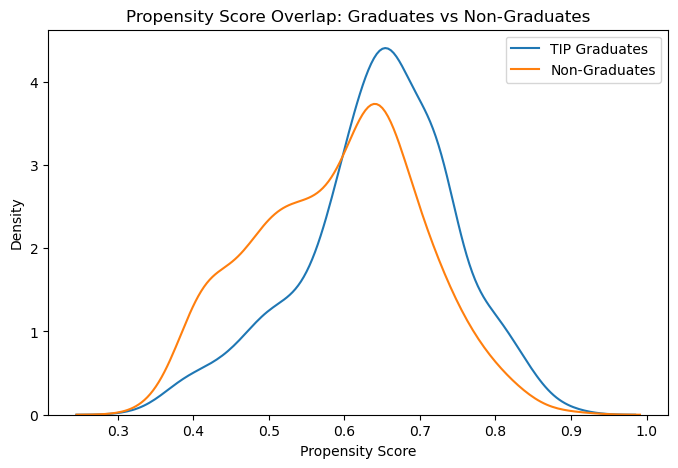


Propensity score summary by treatment:
           count      mean       std       min       25%       50%       75%  \
treatment                                                                      
0          434.0  0.591981  0.107992  0.341509  0.507773  0.609071  0.668431   
1          720.0  0.643273  0.102147  0.327264  0.589786  0.652858  0.714894   

                max  
treatment            
0          0.895149  
1          0.902676  


In [404]:
# 3. Estimate propensity scores and inspect overlap

# Propensity score model uses pre-treatment covariates only
psm_covariates = X_values.drop(columns=['treatment']).copy()

psm_model = LogisticRegression(max_iter=2000, random_state=42)
psm_model.fit(psm_covariates, analysis_df['treatment'])

psm_diagnostics = psm_covariates.copy()
psm_diagnostics['pscore'] = psm_model.predict_proba(psm_covariates)[:, 1]
psm_diagnostics['treatment'] = analysis_df['treatment'].astype(int).values

plt.figure(figsize=(8, 5))
sns.kdeplot(
    psm_diagnostics.loc[psm_diagnostics['treatment'] == 1, 'pscore'],
    label='TIP Graduates'
)
sns.kdeplot(
    psm_diagnostics.loc[psm_diagnostics['treatment'] == 0, 'pscore'],
    label='Non-Graduates'
)
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.title('Propensity Score Overlap: Graduates vs Non-Graduates')
plt.legend()
plt.show()

print("\nPropensity score summary by treatment:")
print(psm_diagnostics.groupby('treatment')['pscore'].describe())

In [405]:
# 4. Run naive logistic regression for employment

X_logit = sm.add_constant(X_values.copy())

logit_has_employment = sm.Logit(Y_has_employment, X_logit).fit()
logit_has_employment.summary()



         Current function value: 0.371566
         Iterations: 35


C:\Users\sarah\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:     employment_outcome   No. Observations:                 1154
Model:                          Logit   Df Residuals:                     1135
Method:                           MLE   Df Model:                           18
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                  0.4459
Time:                        11:27:17   Log-Likelihood:                -428.79
converged:                      False   LL-Null:                       -773.90
Covariance Type:            nonrobust   LLR p-value:                6.718e-135
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          2.5609        nan        nan        nan         nan         nan
treatment                      0.1839      0.176      1.046      0.296      -0.161       0.528
year_TIP                       1.7416      0.171     10.196      0.000       1.407       2.076
num_sentences_before_start    -0.1413      0.115     -1.233      0.218      -0.366       0.083
num_arrests_before_start       0.0619      0.093      0.666      0.506      -0.120       0.244
max_ogs_before_start           0.0317   1.42e+13   2.23e-15      1.000   -2.79e+13    2.79e+13
any_high_ogs_before_start     -0.3940      0.451     -0.873      0.383      -1.279       0.491
log_earnings_1yr_preTIP        3.2029      0.400      8.000      0.000       2.418       3.988
log_earnings_2yr_preTIP       -0.5675      0.371     -1.532      0.126      -1.294       0.159
job_right_before_tip          -4.1585      0.701     -5.932      0.000      -5.532      -2.785
job_2yr_before_tip             1.2299      0.708      1.736      0.082      -0.158       2.618
max_ogs_before_start           0.0317   1.42e+13   2.23e-15      1.000   -2.79e+13    2.79e+13
cohort_2022_1                 -2.4965      0.331     -7.552      0.000      -3.144      -1.849
age_band_35+                  -0.1665      0.239     -0.698      0.485      -0.634       0.301
age_band_<=24                  0.0921      0.201      0.457      0.647      -0.303       0.487
age_band_Unknown              -0.1802      0.326     -0.553      0.580      -0.818       0.458
race_Unknown                 -16.1656   1213.308     -0.013      0.989   -2394.205    2361.874
race_White                    -0.0928      0.272     -0.342      0.733      -0.625       0.440
gender_Male                    0.2869      0.276      1.041      0.298      -0.253       0.827
gender_Unknown                -2.6772   1774.931     -0.002      0.999   -3481.478    3476.124
==============================================================================================
"""

In [406]:
# 5. Display coefficients and sample counts

logit_has_employment_summary = (
    logit_has_employment.summary2().tables[1].reset_index()
)

print(logit_has_employment_summary[['index', 'Coef.', 'P>|z|']])

print("\nTreatment counts:")
print(analysis_df['treatment'].value_counts(dropna=False))

print("\nStatus counts:")
print(analysis_df['Status'].value_counts(dropna=False))

                         index      Coef.         P>|z|
0                        const   2.560882           NaN
1                    treatment   0.183871  2.955598e-01
2                     year_TIP   1.741639  2.059754e-24
3   num_sentences_before_start  -0.141282  2.176457e-01
4     num_arrests_before_start   0.061861  5.056987e-01
5         max_ogs_before_start   0.031726  1.000000e+00
6    any_high_ogs_before_start  -0.393979  3.827172e-01
7      log_earnings_1yr_preTIP   3.202901  1.240399e-15
8      log_earnings_2yr_preTIP  -0.567500  1.256431e-01
9         job_right_before_tip  -4.158509  2.986367e-09
10          job_2yr_before_tip   1.229858  8.248842e-02
11        max_ogs_before_start   0.031726  1.000000e+00
12               cohort_2022_1  -2.496544  4.282628e-14
13                age_band_35+  -0.166472  4.853699e-01
14               age_band_<=24   0.092112  6.473664e-01
15            age_band_Unknown  -0.180169  5.801177e-01
16                race_Unknown -16.165647  9.893

# Matching

In [407]:
matching_df = grad_non_grad.copy()

# Keep needed variables
matching_df = matching_df[
    [
        'tip_id',
        'Status',
        'treatment',
        'StartDate',
        'year_TIP',
        'year_end_TIP',
        'cohort_2022',
        'Age_at_start',
        'age_band',
        'race',
        'gender',
        'census_tract',
        'any_sentence_before_start',
        'num_sentences_before_start',
        'max_ogs_before_start',
        'any_high_ogs_before_start',
        'any_arrest_before_start',
        'num_arrests_before_start',
        'log_earnings_1yr_preTIP',
        'log_earnings_2yr_preTIP',
        'job_right_before_tip',
        'job_2yr_before_tip',
        'employment_outcome',
        'earnings_outcome',
        'offense_outcome',
        'arrest_outcome'
    ]
].copy()

# Clean matching variables
matching_df = matching_df.dropna(subset=['cohort_2022', 'age_band', 'race', 'gender']).copy()

matching_df['cohort_2022'] = matching_df['cohort_2022'].astype(int)
matching_df['age_band'] = matching_df['age_band'].astype(str)
matching_df['race'] = matching_df['race'].astype(str)
matching_df['gender'] = matching_df['gender'].astype(str)

print("matching_df shape:", matching_df.shape)
print("\nTreatment counts:")
print(matching_df['treatment'].value_counts(dropna=False))
print(matching_df['cohort_2022'].value_counts(dropna=False))

print("\nExact-match strata counts:")
print(
    matching_df.groupby(['cohort_2022', 'race', 'gender', 'age_band'])
    .size()
    .reset_index(name='n')
    .sort_values(['cohort_2022', 'race', 'gender', 'age_band'])
)


# Covariates for propensity score model
psm_vars = [
    #'year_TIP',  # maybe we want to reconsider this in the future - may be redundant
    #'num_sentences_before_start',
    'num_arrests_before_start',
    'max_ogs_before_start',
    'log_earnings_1yr_preTIP',
    'log_earnings_2yr_preTIP',
    'job_right_before_tip'
    #'job_2yr_before_tip'
]

continuous_vars = [
 #   'year_TIP',
#    'num_sentences_before_start',
    'num_arrests_before_start',
    'log_earnings_1yr_preTIP',
    'log_earnings_2yr_preTIP'
]

matching_df shape: (1054, 26)

Treatment counts:
treatment
1    651
0    403
Name: count, dtype: int64
cohort_2022
0    775
1    279
Name: count, dtype: int64

Exact-match strata counts:
    cohort_2022     race   gender age_band    n
0             0    Black   Female    25-34   16
1             0    Black   Female      35+    9
2             0    Black   Female     <=24   17
3             0    Black     Male    25-34  294
4             0    Black     Male      35+  119
5             0    Black     Male     <=24  193
6             0  Unknown     Male    25-34    4
7             0  Unknown  Unknown    25-34   19
8             0  Unknown  Unknown      35+    9
9             0  Unknown  Unknown     <=24   15
10            0    White   Female    25-34    3
11            0    White   Female     <=24    5
12            0    White     Male    25-34   35
13            0    White     Male      35+   19
14            0    White     Male     <=24   18
15            1    Black   Female    25-34   

In [408]:
def nearest_neighbor_match_within_strata_with_psm(
    df,
    exact_vars,
    psm_vars,
    continuous_vars,
    treatment_col='treatment',
    id_col='tip_id',
    caliper=0.20
):
    """
    1:1 nearest-neighbor matching without replacement.

    Step 1: exact match by strata
    Step 2: within each stratum, estimate propensity scores
    Step 3: within each stratum, match on propensity score distance
    """
    matched_rows = []
    pair_id = 1

    # Loop over exact-match strata first
    for strata_values, strata_df in df.groupby(exact_vars, dropna=False):
        strata_df = strata_df.copy()

        treated_df = strata_df[strata_df[treatment_col] == 1].copy()
        control_df = strata_df[strata_df[treatment_col] == 0].copy()

        # Need both treated and control in the stratum
        if len(treated_df) == 0 or len(control_df) == 0:
            continue

        # Build propensity score model within stratum
        psm_covariates = strata_df[psm_vars].copy()

        # Standardize continuous variables within stratum
        scaler = StandardScaler()
        psm_covariates[continuous_vars] = scaler.fit_transform(psm_covariates[continuous_vars])

        # Fit logistic regression for propensity score within stratum
        psm_model = LogisticRegression(max_iter=2000, random_state=42)
        psm_model.fit(psm_covariates, strata_df[treatment_col])

        strata_df['pscore'] = psm_model.predict_proba(psm_covariates)[:, 1]

        treated_df = strata_df[strata_df[treatment_col] == 1].copy()
        control_df = strata_df[strata_df[treatment_col] == 0].copy()

        treated_df = treated_df.sort_values('pscore').reset_index(drop=True)
        control_df = control_df.sort_values('pscore').reset_index(drop=True)

        matched_control_ids = set()

        # Nearest-neighbor matching within this exact stratum
        for _, treated_row in treated_df.iterrows():
            eligible_controls = control_df[
                ~control_df[id_col].isin(matched_control_ids)
            ].copy()

            if len(eligible_controls) == 0:
                continue

            eligible_controls['pscore_diff'] = np.abs(
                eligible_controls['pscore'] - treated_row['pscore']
            )

            eligible_controls = eligible_controls[
                eligible_controls['pscore_diff'] <= caliper
            ].copy()

            if len(eligible_controls) == 0:
                continue

            best_control = eligible_controls.sort_values('pscore_diff').iloc[0]

            treated_out = treated_row.to_dict()
            treated_out['match_pair_id'] = pair_id
            treated_out['match_role'] = 'treated'
            treated_out['matched_to_id'] = best_control[id_col]
            treated_out['match_pscore_diff'] = abs(treated_row['pscore'] - best_control['pscore'])

            control_out = best_control.to_dict()
            control_out['match_pair_id'] = pair_id
            control_out['match_role'] = 'control'
            control_out['matched_to_id'] = treated_row[id_col]
            control_out['match_pscore_diff'] = abs(treated_row['pscore'] - best_control['pscore'])

            matched_rows.append(treated_out)
            matched_rows.append(control_out)

            matched_control_ids.add(best_control[id_col])
            pair_id += 1

    matched_df = pd.DataFrame(matched_rows)
    return matched_df


exact_match_vars = ['cohort_2022', 'race', 'gender', 'age_band']

matched_grad_non_grad = nearest_neighbor_match_within_strata_with_psm(
    df=matching_df,
    exact_vars=exact_match_vars,
    psm_vars=psm_vars,
    continuous_vars=continuous_vars,
    treatment_col='treatment',
    id_col='tip_id',
    caliper=0.10
)

print("matched_grad_non_grad shape:", matched_grad_non_grad.shape)
print("\nMatched pair count:", matched_grad_non_grad['match_pair_id'].nunique())

print("\nMatched treatment counts:")
print(matched_grad_non_grad['treatment'].value_counts(dropna=False))

if 'pscore' in matched_grad_non_grad.columns:
    print("\nMatched propensity score summary:")
    print(matched_grad_non_grad.groupby('treatment')['pscore'].describe())

matched_grad_non_grad shape: (702, 32)

Matched pair count: 351

Matched treatment counts:
treatment
1    351
0    351
Name: count, dtype: int64

Matched propensity score summary:
           count      mean       std       min       25%       50%       75%  \
treatment                                                                      
0          351.0  0.579940  0.113988  0.299536  0.455646  0.588371  0.673880   
1          351.0  0.566933  0.102799  0.303808  0.458169  0.583284  0.659262   

                max  
treatment            
0          0.921876  
1          0.888816  


In [409]:
print("Matched status counts:")
print(matched_grad_non_grad['Status'].value_counts(dropna=False))
print(matched_grad_non_grad['cohort_2022'].value_counts(dropna=False))

print("\nMatched exact strata check:")
print(
    matched_grad_non_grad.groupby(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
    .size()
    .reset_index(name='n')
    .sort_values(['cohort_2022', 'race', 'gender', 'age_band', 'treatment'])
)

print("\nAverage propensity score difference within matched pairs:")
print(matched_grad_non_grad[['match_pair_id', 'match_pscore_diff']].drop_duplicates()['match_pscore_diff'].describe())

Matched status counts:
Status
Graduated        351
Non Graduated    351
Name: count, dtype: int64
cohort_2022
0    552
1    150
Name: count, dtype: int64

Matched exact strata check:
    cohort_2022     race   gender age_band  treatment    n
0             0    Black   Female    25-34          0    5
1             0    Black   Female    25-34          1    5
2             0    Black   Female      35+          0    2
3             0    Black   Female      35+          1    2
4             0    Black   Female     <=24          0    6
5             0    Black   Female     <=24          1    6
6             0    Black     Male    25-34          0  106
7             0    Black     Male    25-34          1  106
8             0    Black     Male      35+          0   34
9             0    Black     Male      35+          1   34
10            0    Black     Male     <=24          0   86
11            0    Black     Male     <=24          1   86
12            0  Unknown     Male    25-34        

In [410]:
matched_grad_non_grad.groupby('treatment')['cohort_2022'].value_counts()

treatment  cohort_2022
0          0              276
           1               75
1          0              276
           1               75
Name: count, dtype: int64

In [411]:
treated_pairs = matched_grad_non_grad[
    matched_grad_non_grad['match_role'] == 'treated'
][
    ['match_pair_id', 'tip_id', 'pscore', 'cohort_2022', 'race', 'gender', 'age_band', 'match_pscore_diff']
].rename(columns={
    'tip_id': 'treated_tip_id',
    'pscore': 'treated_pscore'
})

control_pairs = matched_grad_non_grad[
    matched_grad_non_grad['match_role'] == 'control'
][
    ['match_pair_id', 'tip_id', 'pscore']
].rename(columns={
    'tip_id': 'control_tip_id',
    'pscore': 'control_pscore'
})

matched_pair_summary = treated_pairs.merge(control_pairs, on='match_pair_id', how='inner')

matched_pair_summary.head(20)



,match_pair_id,treated_tip_id,treated_pscore,cohort_2022,race,gender,age_band,match_pscore_diff,control_tip_id,control_pscore
0,1,963,0.504394,0,Black,Female,25-34,0.018562,1416,0.522957
1,2,1032,0.604803,0,Black,Female,25-34,0.020000,1427,0.624803
2,3,1331,0.611034,0,Black,Female,25-34,0.014361,41,0.625395
3,4,1419,0.615187,0,Black,Female,25-34,0.010208,51,0.625395
4,5,772,0.721974,0,Black,Female,25-34,0.013064,1190,0.735038
5,6,198,0.450170,0,Black,Female,35+,0.000000,499,0.450170
6,7,1102,0.669046,0,Black,Female,35+,0.043358,1424,0.712403
7,8,996,0.303808,0,Black,Female,<=24,0.004272,1434,0.299536
8,9,536,0.439261,0,Black,Female,<=24,0.000000,83,0.439261
9,10,744,0.439261,0,Black,Female,<=24,0.000000,173,0.439261


In [412]:
matched_grad_non_grad = matched_grad_non_grad.sort_values(
    ['match_pair_id', 'match_role']
).reset_index(drop=True)

print("Final matched analysis file shape:", matched_grad_non_grad.shape)

matched_grad_non_grad.head()

matched_grad_non_grad.columns

Final matched analysis file shape: (702, 32)


Index(['tip_id', 'Status', 'treatment', 'StartDate', 'year_TIP',
       'year_end_TIP', 'cohort_2022', 'Age_at_start', 'age_band', 'race',
       'gender', 'census_tract', 'any_sentence_before_start',
       'num_sentences_before_start', 'max_ogs_before_start',
       'any_high_ogs_before_start', 'any_arrest_before_start',
       'num_arrests_before_start', 'log_earnings_1yr_preTIP',
       'log_earnings_2yr_preTIP', 'job_right_before_tip', 'job_2yr_before_tip',
       'employment_outcome', 'earnings_outcome', 'offense_outcome',
       'arrest_outcome', 'pscore', 'match_pair_id', 'match_role',
       'matched_to_id', 'match_pscore_diff', 'pscore_diff'],
      dtype='object')

# Matched Sample Diagnostics and Preliminary Outcome Comparisons

Now that we have constructed the matched graduate vs. non-graduate sample, the next step is to evaluate whether the matched sample is sufficiently balanced and to summarize outcome differences before running formal matched regressions.

This section has two goals.

First, we examine **matched sample diagnostics**. We compare the treatment and control groups on key pre-TIP covariates and compute standardized mean differences (SMDs). This helps us assess whether the matching procedure improved comparability between graduates and non-graduates.

Second, we present **simple matched outcome comparisons**. For the matched sample, we compare average employment, earnings, offense, and arrest outcomes between graduates and non-graduates. These comparisons are descriptive and are intended to show the direction and magnitude of differences after matching.

These results are not yet the final adjusted estimates. If residual imbalance remains for some baseline variables, those variables should be controlled for in the next matched regression step.m

In [413]:
matched_analysis = matched_grad_non_grad.copy()

print("Matched sample size:", len(matched_analysis))
print("Matched pair count:", matched_analysis['match_pair_id'].nunique())

print("\nTreatment counts:")
print(matched_analysis['treatment'].value_counts(dropna=False))

print("\nStatus counts:")
print(matched_analysis['Status'].value_counts(dropna=False))

print("\nCohort by treatment:")
print(pd.crosstab(matched_analysis['cohort_2022'], matched_analysis['treatment'], margins=True))

print("\nAge band by treatment:")
print(pd.crosstab(matched_analysis['age_band'], matched_analysis['treatment'], margins=True))

print("\nRace by treatment:")
print(pd.crosstab(matched_analysis['race'], matched_analysis['treatment'], margins=True))

print("\nGender by treatment:")
print(pd.crosstab(matched_analysis['gender'], matched_analysis['treatment'], margins=True))



Matched sample size: 702
Matched pair count: 351

Treatment counts:
treatment
0    351
1    351
Name: count, dtype: int64

Status counts:
Status
Non Graduated    351
Graduated        351
Name: count, dtype: int64

Cohort by treatment:
treatment      0    1  All
cohort_2022               
0            276  276  552
1             75   75  150
All          351  351  702

Age band by treatment:
treatment    0    1  All
age_band                
25-34      151  151  302
35+         45   45   90
<=24       155  155  310
All        351  351  702

Race by treatment:
treatment    0    1  All
race                    
Black      307  307  614
Unknown     21   21   42
White       23   23   46
All        351  351  702

Gender by treatment:
treatment    0    1  All
gender                  
Female      25   25   50
Male       306  306  612
Unknown     20   20   40
All        351  351  702


In [414]:
matched_analysis.columns



Index(['tip_id', 'Status', 'treatment', 'StartDate', 'year_TIP',
       'year_end_TIP', 'cohort_2022', 'Age_at_start', 'age_band', 'race',
       'gender', 'census_tract', 'any_sentence_before_start',
       'num_sentences_before_start', 'max_ogs_before_start',
       'any_high_ogs_before_start', 'any_arrest_before_start',
       'num_arrests_before_start', 'log_earnings_1yr_preTIP',
       'log_earnings_2yr_preTIP', 'job_right_before_tip', 'job_2yr_before_tip',
       'employment_outcome', 'earnings_outcome', 'offense_outcome',
       'arrest_outcome', 'pscore', 'match_pair_id', 'match_role',
       'matched_to_id', 'match_pscore_diff', 'pscore_diff'],
      dtype='object')

In [415]:
balance_vars = [
    'year_TIP',
    'num_sentences_before_start',
    'max_ogs_before_start',
    'num_arrests_before_start',
    'log_earnings_1yr_preTIP',
    'log_earnings_2yr_preTIP',
    'job_right_before_tip',
    'job_2yr_before_tip'
    
]

balance_table = matched_analysis.groupby('treatment')[balance_vars].mean().T
balance_table.columns = ['matched_control_mean', 'matched_treated_mean']
balance_table['difference'] = (
    balance_table['matched_treated_mean'] - balance_table['matched_control_mean']
)

balance_table

,matched_control_mean,matched_treated_mean,difference
year_TIP,2018.279202,2018.680912,0.401709
num_sentences_before_start,1.925926,2.544160,0.618234
max_ogs_before_start,2.566952,3.059829,0.492877
num_arrests_before_start,1.156695,1.105413,-0.051282
log_earnings_1yr_preTIP,3.730553,4.357816,0.627263
log_earnings_2yr_preTIP,3.012633,3.259274,0.246641
job_right_before_tip,0.433048,0.495726,0.062678
job_2yr_before_tip,0.390313,0.424501,0.034188


In [416]:
def standardized_mean_diff(df, treatment_col, var):
    treated = df[df[treatment_col] == 1][var].dropna()
    control = df[df[treatment_col] == 0][var].dropna()

    mean_t = treated.mean()
    mean_c = control.mean()

    var_t = treated.var()
    var_c = control.var()

    pooled_sd = np.sqrt((var_t + var_c) / 2)

    if pooled_sd == 0:
        return 0

    return (mean_t - mean_c) / pooled_sd

smd_results = []
for var in balance_vars:
    smd_results.append({
        'variable': var,
        'SMD': standardized_mean_diff(matched_analysis, 'treatment', var)
    })

smd_table = pd.DataFrame(smd_results).sort_values('SMD', key=lambda x: x.abs(), ascending=False)
smd_table

,variable,SMD
1,num_sentences_before_start,0.151277
4,log_earnings_1yr_preTIP,0.141107
2,max_ogs_before_start,0.126839
6,job_right_before_tip,0.125745
0,year_TIP,0.117520
7,job_2yr_before_tip,0.069522
5,log_earnings_2yr_preTIP,0.057977
3,num_arrests_before_start,-0.017587


Matched pair propensity-score difference summary:
count    351.000000
mean       0.015735
std        0.022529
min        0.000000
25%        0.000271
50%        0.007856
75%        0.019022
max        0.098439
Name: match_pscore_diff, dtype: float64


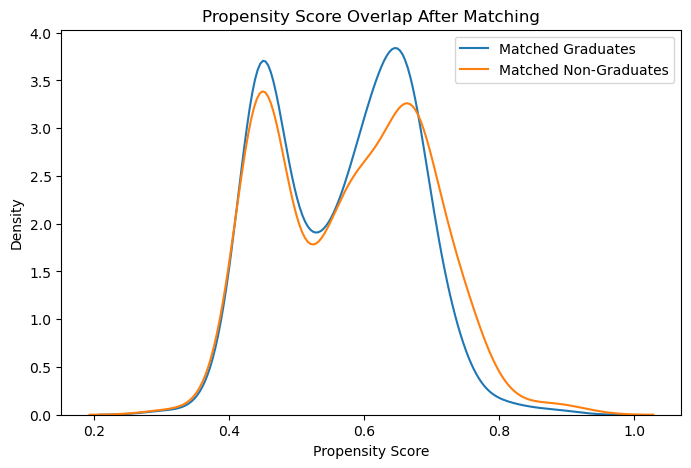

In [417]:


print("Matched pair propensity-score difference summary:")
print(
    matched_analysis[['match_pair_id', 'match_pscore_diff']]
    .drop_duplicates()['match_pscore_diff']
    .describe()
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(
    matched_analysis.loc[matched_analysis['treatment'] == 1, 'pscore'],
    label='Matched Graduates'
)
sns.kdeplot(
    matched_analysis.loc[matched_analysis['treatment'] == 0, 'pscore'],
    label='Matched Non-Graduates'
)
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.title('Propensity Score Overlap After Matching')
plt.legend()
plt.show()



In [418]:
outcome_vars = [
    'employment_outcome',
    'earnings_outcome',
    'offense_outcome',
    'arrest_outcome'
]

matched_outcome_table = matched_analysis.groupby('treatment')[outcome_vars].mean().T
matched_outcome_table.columns = ['matched_control_mean', 'matched_treated_mean']
matched_outcome_table['difference'] = (
    matched_outcome_table['matched_treated_mean'] - matched_outcome_table['matched_control_mean']
)

matched_outcome_table

,matched_control_mean,matched_treated_mean,difference
employment_outcome,0.601140,0.669516,0.068376
earnings_outcome,10119.380964,12574.449780,2455.068815
offense_outcome,0.071225,0.082621,0.011396
arrest_outcome,0.111111,0.099715,-0.011396


In [419]:
#create year variable in tip_sentencing that maps to the year on the DOS for each record
tip_sentencing = tip_sentencing.dropna(subset=['DOS'])
tip_sentencing['year'] = tip_sentencing['DOS'].dt.year.astype(int)

#set up all_tip_data as a dict for easier lookup when creating panel data frame
all_tip_data_dict = grad_non_grad.set_index('tip_id').to_dict(orient='index')

In [420]:
#check for any non-1's in offense_indicator, to see whether we should still select on this moving forward in logic
tip_sentencing["offense_indicator"].value_counts(dropna = False)

offense_indicator
1    7320
0       1
Name: count, dtype: int64

In [421]:
#establish time-variant participated_tip variable
def participated_tip(tip_id, year):
    #filter grad_non_grad data frame to rows where tip_id matches the inputted tip_id AND the year_end_TIP for that tip_id is less than or equal to
    #the year inputted (e.g. - checks if the tip_id has finished TIP by the year inputted into the function)
    if len(grad_non_grad[(grad_non_grad['tip_id'] == tip_id) & (grad_non_grad['year_end_TIP'] <= year)]) > 0:
        #if the filtered dataset has rows > 0, return 1 (participated tip by this time)
        return 1
    else:
        #else 0 (did not finish participation in TIP by this point)
        return 0

#establish time-variant graduated_tip variable
def graduated_tip(tip_id, year):
    #filter grad_non_grad data frame to rows where tip_id matches the inputted tip_id AND the year_end_TIP for that tip_id is less than or equal to
    #the year inputted (e.g. - checks if the tip_id has finished TIP by the year inputted into the function)
    #AND the status of the individuals is a Graduate
    if len(grad_non_grad[(grad_non_grad['tip_id'] == tip_id) & (grad_non_grad['year_end_TIP'] <= year) & (grad_non_grad['Status'] == 'Graduated')]) > 0:
        #if the filtered dataset has rows > 0, return 1 (participated tip by this time AND is a graduate)
        return 1
    else:
        #else 0 (did not finish participation in TIP by this point and/or is not a Graduate)
        return 0

#establish time-variant employment variable
def employed_full_year(tip_id, year):
    # Filter earnings data for the specific person and year, AND only rows where earnings > 0
    earnings = tip_earnings[
        (tip_earnings['tip_id'] == tip_id) & 
        (tip_earnings['year'] == year) & 
        (tip_earnings['adjusted_earnings'] > 0)
    ]
    # if there are no rows in the filtered dataframe, not employed at all that year (0)
    if len(earnings) == 0:
        return 0
    
    #if there are rows in the filtered data frame, check if they were employed for all 4 quarters
    #(rows == 4)
    if earnings['year_quarter_dt'].nunique() == 4:
        return 1
    else:
        return 0

#establish time-variant partial employment variable
def employed_partial_year(tip_id, year):
    # Filter earnings data for the specific person and year, AND only rows where earnings > 0
    earnings = tip_earnings[(tip_earnings['tip_id'] == tip_id) & (tip_earnings['year'] == year) & (tip_earnings['adjusted_earnings'] > 0)]
    # if 0, never employed that year
    if len(earnings) == 0:
        return 0
    else:
        #if the number of unique dates in the filtered dataframe is >0, they were employed at some point, returns 1
        if earnings['year_quarter_dt'].nunique() > 0:
            return 1
        else:
            return 0

#establish time-variant calculation of earnings for the year
def earnings_full_year(tip_id, year):
    #filter earnings data to rows that match the tip_id and inputted year
    earnings = tip_earnings[(tip_earnings['tip_id'] == tip_id) & (tip_earnings['year'] == year)]
    #return the sum of adjusted earnings in the filtered rows. If no rows, report 0 earnings
    return earnings['adjusted_earnings'].sum() if len(earnings) > 0 else 0

#establish time-variant offense count for the year
def offense_count_full_year(tip_id, year):
    #filter offense data to rows that match the tip_id and inputted year
    offenses = tip_sentencing[(tip_sentencing['tip_id'] == tip_id) & (tip_sentencing['year'] == year)]
    #if there are rows, return the number of rows (number of offenses within the year)
    if len(offenses) > 0:
        return len(offenses)
    else:
        return 0

#establish time variant binary offense indicator for the year
def has_offense_full_year(tip_id, year):
    #filter offense data to rows that match the tip_id and year
    offenses = tip_sentencing[(tip_sentencing['tip_id'] == tip_id) & (tip_sentencing['year'] == year) & (tip_sentencing['offense_indicator'] == 1)]
    #if there are rows, return 1 (offense indicator) else 0
    if len(offenses) > 0:
        return 1
    else:
        return 0

def has_offense_by(tip_id, year):
    #filter offense data to rows that match the tip ID and rows that are within or before the year of interest
    offenses = tip_sentencing[(tip_sentencing['tip_id'] == tip_id) & (tip_sentencing['year'] <= year) & (tip_sentencing['offense_indicator'] == 1)]
    #if there are any rows, return 1 (offense by that time indicator) else 0
    if len(offenses) > 0:
        return 1
    else:
        return 0

def has_offense_previous(tip_id, year):
    #filter offense data to rows that match the tip ID and rows that are strictly before the year of interest
    offenses = tip_sentencing[(tip_sentencing['tip_id'] == tip_id) & (tip_sentencing['year'] < year) & (tip_sentencing['offense_indicator'] == 1)]
    #if there are any rows, return 1 (offense by that time indicator) else 0
    if len(offenses) > 0:
        return 1
    else:
        return 0

In [422]:
#Create the panel data frame
panel_df = []

#for each tip id in our matched sample
for tip_id in matched_grad_non_grad.tip_id.unique():
    #for years between 2017 and 2025
    for year in range(2017, 2025):
        panel_df.append({
            #pull in time-invariant fields from our data dict
            'tip_id': tip_id,
            'year': year,
            'treatment': all_tip_data_dict[tip_id]['treatment'] if tip_id in all_tip_data_dict else 'Unknown',
            'end_year': all_tip_data_dict[tip_id]['year_end_TIP'] if tip_id in all_tip_data_dict else 'Unknown',
            'StartDate' : all_tip_data_dict[tip_id]['StartDate'] if tip_id in all_tip_data_dict else 'Unknown',
            'EndDate' : all_tip_data_dict[tip_id]['EndDate'] if tip_id in all_tip_data_dict else 'Unknown',
            'Status' : all_tip_data_dict[tip_id]['Status'] if tip_id in all_tip_data_dict else 'Unknown',
            'age_band': all_tip_data_dict[tip_id]['age_band'] if tip_id in all_tip_data_dict else 'Unknown',
            'cohort_2022' : all_tip_data_dict[tip_id]['cohort_2022'] if tip_id in all_tip_data_dict else 'Unknown',
            'race': tip_demos[tip_id]['race'] if tip_id in tip_demos else 'Unknown',
            'gender': tip_demos[tip_id]['gender'] if tip_id in tip_demos else 'Unknown',
            'census_tract': int(tip_demos[tip_id]['census_tract']) if tip_id in tip_demos and not pd.isnull(tip_demos[tip_id]['census_tract']) else "Unknown",
            #define the time variant variables for each year using the previously established functions
            'participated_tip': participated_tip(tip_id, year),
            'graduated_tip': graduated_tip(tip_id, year),
            'employed_full_year': employed_full_year(tip_id, year),
            'employed_partial_year': employed_partial_year(tip_id, year),
            'earnings_full_year': earnings_full_year(tip_id, year),
            'offense_count_year': offense_count_full_year(tip_id, year),
            'offended_year': has_offense_full_year(tip_id, year),
            'has_offense_by_year': has_offense_by(tip_id, year),
            'has_offense_prior_to_year': has_offense_previous(tip_id, year)
        })

panel_df = pd.DataFrame(panel_df)

#apply the rough EndDate cutoff
cutoff = pd.Timestamp('2018-01-01', tz='UTC')
panel_df = panel_df[panel_df['EndDate'] >= cutoff].copy()

#ensure each person has at least one pre-TIP period in the panel
valid_tip_ids = (
    panel_df.groupby('tip_id')['participated_tip']
    .apply(lambda x: (x == 0).any())
)

valid_tip_ids = valid_tip_ids[valid_tip_ids].index

panel_df = panel_df[panel_df['tip_id'].isin(valid_tip_ids)].copy()

In [423]:
panel_df.columns

Index(['tip_id', 'year', 'treatment', 'end_year', 'StartDate', 'EndDate',
       'Status', 'age_band', 'cohort_2022', 'race', 'gender', 'census_tract',
       'participated_tip', 'graduated_tip', 'employed_full_year',
       'employed_partial_year', 'earnings_full_year', 'offense_count_year',
       'offended_year', 'has_offense_by_year', 'has_offense_prior_to_year'],
      dtype='object')

In [424]:
matched_grad_non_grad.columns

Index(['tip_id', 'Status', 'treatment', 'StartDate', 'year_TIP',
       'year_end_TIP', 'cohort_2022', 'Age_at_start', 'age_band', 'race',
       'gender', 'census_tract', 'any_sentence_before_start',
       'num_sentences_before_start', 'max_ogs_before_start',
       'any_high_ogs_before_start', 'any_arrest_before_start',
       'num_arrests_before_start', 'log_earnings_1yr_preTIP',
       'log_earnings_2yr_preTIP', 'job_right_before_tip', 'job_2yr_before_tip',
       'employment_outcome', 'earnings_outcome', 'offense_outcome',
       'arrest_outcome', 'pscore', 'match_pair_id', 'match_role',
       'matched_to_id', 'match_pscore_diff', 'pscore_diff'],
      dtype='object')

In [425]:
matched_grad_non_grad.head()

,tip_id,Status,treatment,StartDate,year_TIP,year_end_TIP,cohort_2022,Age_at_start,age_band,race,...,employment_outcome,earnings_outcome,offense_outcome,arrest_outcome,pscore,match_pair_id,match_role,matched_to_id,match_pscore_diff,pscore_diff
0,1416,Non Graduated,0,2021-08-23,2021,2022.0,0,32.358168,25-34,Black,...,1,23295.067689,0,0,0.522957,1,control,963,0.018562,0.018562
1,963,Graduated,1,2019-04-15,2019,2019.0,0,28.049214,25-34,Black,...,1,15261.317839,0,0,0.504394,1,treated,1416,0.018562,NaN
2,1427,Non Graduated,0,2021-09-20,2021,2021.0,0,27.589884,25-34,Black,...,1,24559.683018,0,0,0.624803,2,control,1032,0.020000,0.020000
3,1032,Graduated,1,2019-07-22,2019,2019.0,0,28.021873,25-34,Black,...,0,0.000000,0,0,0.604803,2,treated,1427,0.020000,NaN
4,41,Non Graduated,0,2010-07-20,2010,2010.0,0,31.822283,25-34,Black,...,0,0.000000,0,0,0.625395,3,control,1331,0.014361,0.014361


In [426]:
#Check pre-trends
PRE_YRS         = 3    # years of pre-period to show
POST_YRS        = 2    # years of post-period to show
OMIT_YR         = -1   # reference/omitted period (year just before entry)

panel_df['relative_year'] = panel_df['year'] - panel_df['end_year']
df_panel_event = panel_df[
    (panel_df["relative_year"] >= -PRE_YRS) &
    (panel_df["relative_year"] <= POST_YRS)
    ].copy()

print(f"\nPanel before windowing: {len(panel_df):,} person-year rows")
print(f"\nPanel after windowing: {len(df_panel_event):,} person-year rows")
print(f"  Relative years: {sorted(df_panel_event['relative_year'].unique())}")




Panel before windowing: 3,656 person-year rows

Panel after windowing: 2,378 person-year rows
  Relative years: [np.float64(-3.0), np.float64(-2.0), np.float64(-1.0), np.float64(0.0), np.float64(1.0), np.float64(2.0)]


In [427]:
df_panel_event['log_earnings'] = np.log(df_panel_event['earnings_full_year'] + 1)

df_pre22  = df_panel_event[df_panel_event['end_year'] < 2022].copy()
df_post22 = df_panel_event[df_panel_event['end_year'] >= 2022].copy()

def event_name(k):
    return f"event_m{abs(k)}" if k < 0 else f"event_p{k}"

# Create dummies + mapping
event_map = {}

for k in range(-PRE_YRS, POST_YRS + 1):
    name = event_name(k)
    df_pre22[name] = (df_pre22['relative_year'] == k).astype(int)
    df_post22[name] = (df_post22['relative_year'] == k).astype(int)
    event_map[name] = k

event_dummies = [event_name(k) for k in range(-PRE_YRS, POST_YRS + 1) if k != OMIT_YR]

outcomes = ['log_earnings', 'employed_partial_year', 'offended_year']
results_pre22_dict = {}
results_post22_dict = {}

for outcome in outcomes:
    formula = f"{outcome} ~ " + " + ".join(event_dummies) + " + C(tip_id) + C(year)"
    
    model = smf.ols(formula, data=df_pre22).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_pre22['tip_id']}
    )
    
    coefs = model.params.filter(like='event_')
    ses = model.bse.filter(like='event_')
    
    df_res = pd.DataFrame({
        'event_time': [event_map[x] for x in coefs.index],  # ✅ FIXED
        'coef': coefs.values,
        'se': ses.values
    }).sort_values('event_time')
    
    df_res['ci_lower'] = df_res['coef'] - 1.96 * df_res['se']
    df_res['ci_upper'] = df_res['coef'] + 1.96 * df_res['se']
    
    results_pre22_dict[outcome] = df_res


for outcome in outcomes:
    formula = f"{outcome} ~ " + " + ".join(event_dummies) + " + C(tip_id) + C(year)"
    
    model = smf.ols(formula, data=df_post22).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_post22['tip_id']}
    )
    
    coefs = model.params.filter(like='event_')
    ses = model.bse.filter(like='event_')
    
    df_res = pd.DataFrame({
        'event_time': [event_map[x] for x in coefs.index],  # ✅ FIXED
        'coef': coefs.values,
        'se': ses.values
    }).sort_values('event_time')
    
    df_res['ci_lower'] = df_res['coef'] - 1.96 * df_res['se']
    df_res['ci_upper'] = df_res['coef'] + 1.96 * df_res['se']
    
    results_post22_dict[outcome] = df_res

C:\Users\sarah\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
C:\Users\sarah\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
C:\Users\sarah\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
C:\Users\sarah\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


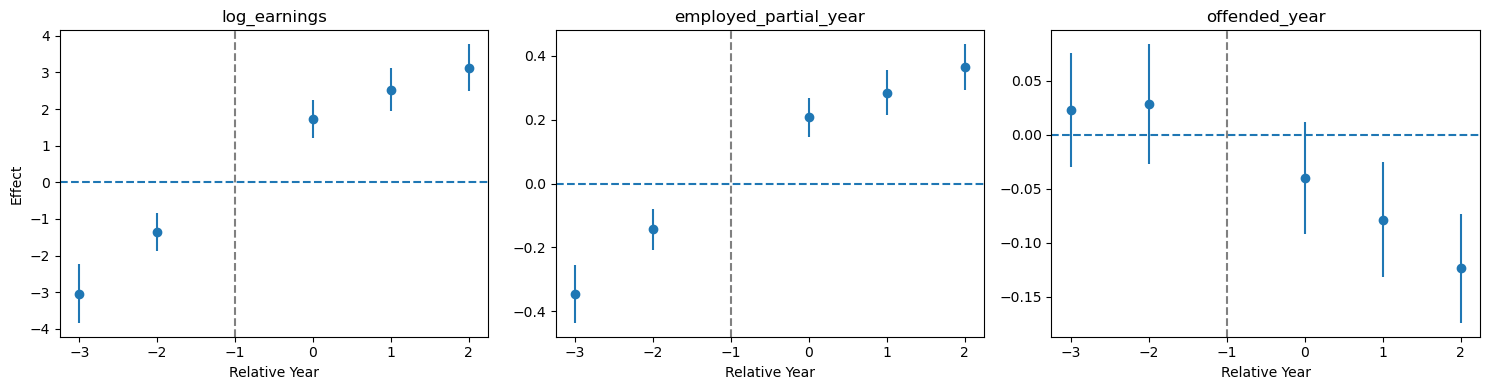

In [428]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

for ax, outcome in zip(axes, outcomes):
    df_res = results_pre22_dict[outcome]
    
    ax.errorbar(df_res['event_time'], df_res['coef'],
                yerr=1.96 * df_res['se'], fmt='o')
    
    ax.axhline(0, linestyle='--')
    ax.axvline(OMIT_YR, linestyle='--', color='gray')
    
    ax.set_title(outcome)
    ax.set_xlabel("Relative Year")

axes[0].set_ylabel("Effect")

plt.tight_layout()
plt.show()

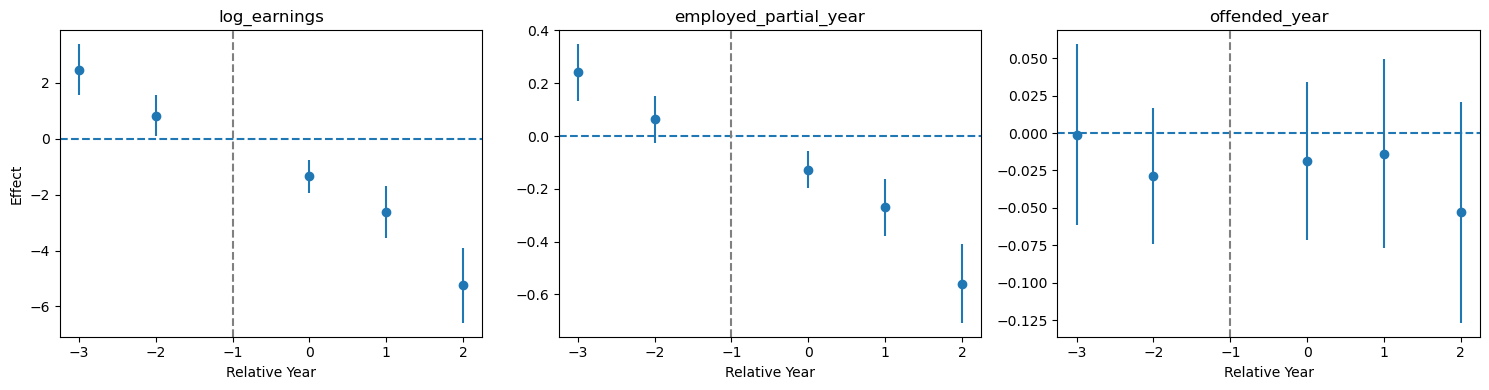

In [429]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

for ax, outcome in zip(axes, outcomes):
    df_res = results_post22_dict[outcome]
    
    ax.errorbar(df_res['event_time'], df_res['coef'],
                yerr=1.96 * df_res['se'], fmt='o')
    
    ax.axhline(0, linestyle='--')
    ax.axvline(OMIT_YR, linestyle='--', color='gray')
    
    ax.set_title(outcome)
    ax.set_xlabel("Relative Year")

axes[0].set_ylabel("Effect")

plt.tight_layout()
plt.show()

# Two-Way Fixed Effects Model for Criminal Justice Interactions

We will create a fixed effects model that estimates the impact of Graduating TIP on the employment of TIP Participants and how this varies by cohort:

$$
\text{Offended}_{it} = \alpha_i + \gamma_t + \beta * \text{Graduated\_TIP}_{it} + \delta * \text{Graduated\_TIP}_{it}* \text{Cohort\_TIP}_{i} + \zeta * \text{Has\_Offense\_Prior\_To\_Year}_{it} + + \epsilon_{it}
$$

Where:
- $\text{Offended}_{it}$ is a binary variable indicating whether individual $i$ offended in year $t$.
- $\alpha_i$ is the individual fixed effect.
- $\gamma_t$ is the time fixed effect.
- $\text{Graduated\_TIP}_{it}$ is a binary interaction term indicating whether individual $i$ is a graduate from TIP by time $t$. It evaluates to 0 if the participant is a non-graduate of TIP or if the participant has not graduated from TIP at time $t$. 
- $\text{Graduated\_TIP}_{i}* \text{Cohort\_TIP}_{i} $ is a binary interaction term indicating whether individual $i$ is a graduate in the post-2022 cohort by time $t$. It evaluates to 0 if the participant is a non-graduate, if the participant is in the pre-2022 cohort, or if the participant is a graduate in the post-2022 cohort but has not graduated from TIP at time $t$.
- $\text{Has\_Offense\_Prior\_To\_Year}_{it}$ is a binary variable indicating whether individual $i$ has offended at all prior time $t$.
- $\beta$ is the coefficient for the Graduated_TIP * post TIP interaction term.
- $\delta$ is the coefficient for the Graduated_TIP * post TIP * cohort_2022 interaction term.
- $\zeta$ is the coefficient for the Has_Offense_By variable.
- $\epsilon_{it}$ is the error term.

In [ ]:
#Conditional logit for offenses
#Goal: Check treatment impact on employment post-TIP, treatment impact on employment post-TIP by cohort_2022
#Control for time effects (year dummies), individual fixed effects, and whether the individual has offended or not by each year

#get dummies for year
year_dummies = pd.get_dummies(panel_df['year'], prefix='year', drop_first=True).astype(float)

#Interaction term
panel_df['graduatedXcohort'] = panel_df['graduated_tip']*panel_df['cohort_2022']

#define X
X = pd.concat([
    panel_df[['has_offense_prior_to_year', 'graduated_tip', 'graduatedXcohort']],
    year_dummies
], axis=1)

from statsmodels.discrete.conditional_models import ConditionalLogit

model = ConditionalLogit(
    endog=panel_df['offended_year'],
    exog=X,
    #fixed effects for individual
    groups=panel_df['tip_id']
).fit()

print(model.summary())

In [ ]:
results = model 

summary_df = pd.DataFrame({
    "coef": results.params,
    "std_err": results.bse,
    "z": results.tvalues,
    "p_value": results.pvalues,
    "ci_lower": results.conf_int()[0],
    "ci_upper": results.conf_int()[1]
})

summary_df["odds_ratio"] = np.exp(summary_df["coef"])
summary_df["or_lower"] = np.exp(summary_df["ci_lower"])
summary_df["or_upper"] = np.exp(summary_df["ci_upper"])

summary_df["pct_change"] = (summary_df["odds_ratio"] - 1) * 100

summary_df_sorted = summary_df.sort_values("odds_ratio", ascending=False)
print(summary_df_sorted)

key_vars = [
    "has_offense_prior_to_year",
    "graduated_tip",
    "graduatedXcohort"
]

summary_df.loc[key_vars]

for var in key_vars:
    or_val = summary_df.loc[var, "odds_ratio"]
    p_val = summary_df.loc[var, "p_value"]

    print(f"{var}:")
    print(f"  Odds Ratio: {or_val:.3f}")
    print(f"  Percent change: {(or_val - 1) * 100:.1f}%")
    print(f"  p-value: {p_val:.3f}")
    print()

# Two-Way Fixed Effects Model for Employment

We will create a fixed effects model that estimates the impact of Graduating TIP on the employment of TIP Participants and how this varies by cohort:

$$
\text{Employed}_{it} =  \gamma_t + \beta * \text{Graduated\_TIP}_{it} + \delta * \text{Graduated\_TIP}_{it}* \text{Cohort\_TIP}_{i} + \zeta * \text{Has\_Offense\_By}_{it} + + \epsilon_{it}
$$

Where:
- $\text{Employed}_{it}$ is a binary variable indicating whether individual $i$ was employed at all within year $t$.
- $\gamma_t$ is the time fixed effect.
- $\text{Graduated\_TIP}_{it}$ is a binary interaction term indicating whether individual $i$ is a graduate from TIP by time $t$. It evaluates to 0 if the participant is a non-graduate of TIP or if the participant has not graduated from TIP at time $t$. 
- $\text{Graduated\_TIP}_{i}* \text{Cohort\_TIP}_{i} $ is a binary interaction term indicating whether individual $i$ is a graduate in the post-2022 cohort by time $t$. It evaluates to 0 if the participant is a non-graduate, if the participant is in the pre-2022 cohort, or if the participant is a graduate in the post-2022 cohort but has not graduated from TIP at time $t$.
- $\text{Has\_Offense\_By}_{it}$ is a binary variable indicating whether individual $i$ has an offense at time $t$.
- $\beta$ is the coefficient for the Graduated_TIP * post TIP interaction term.
- $\delta$ is the coefficient for the Graduated_TIP * post TIP * cohort_2022 interaction term.
- $\zeta$ is the coefficient for the Has_Offense_By variable.
- $\epsilon_{it}$ is the error term.

In [ ]:
#Conditional logit for employment
#Goal: Check treatment impact on employment post-TIP, treatment impact on employment post-TIP by cohort_2022
#Control for time effects (year dummies), individual fixed effects, and whether the individual has offended or not by each year

#get dummies for year
year_dummies = pd.get_dummies(panel_df['year'], prefix='year', drop_first=True).astype(float)

#Interaction term
panel_df['graduatedXcohort'] = panel_df['graduated_tip']*panel_df['cohort_2022']

#define X
X = pd.concat([
    panel_df[['has_offense_by_year', 'graduated_tip', 'graduatedXcohort']],
    year_dummies
], axis=1)

from statsmodels.discrete.conditional_models import ConditionalLogit

model = ConditionalLogit(
    endog=panel_df['employed_partial_year'],
    exog=X,
    #fixed effects for individual
    groups=panel_df['tip_id']
).fit()

print(model.summary())

In [186]:
results = model 

summary_df = pd.DataFrame({
    "coef": results.params,
    "std_err": results.bse,
    "z": results.tvalues,
    "p_value": results.pvalues,
    "ci_lower": results.conf_int()[0],
    "ci_upper": results.conf_int()[1]
})

summary_df["odds_ratio"] = np.exp(summary_df["coef"])
summary_df["or_lower"] = np.exp(summary_df["ci_lower"])
summary_df["or_upper"] = np.exp(summary_df["ci_upper"])

summary_df["pct_change"] = (summary_df["odds_ratio"] - 1) * 100

summary_df_sorted = summary_df.sort_values("odds_ratio", ascending=False)
print(summary_df_sorted)

key_vars = [
    "has_offense_by_year",
    "graduated_tip",
    "graduatedXcohort"
]

summary_df.loc[key_vars]

for var in key_vars:
    or_val = summary_df.loc[var, "odds_ratio"]
    p_val = summary_df.loc[var, "p_value"]

    print(f"{var}:")
    print(f"  Odds Ratio: {or_val:.3f}")
    print(f"  Percent change: {(or_val - 1) * 100:.1f}%")
    print(f"  p-value: {p_val:.3f}")
    print()

NameError: name 'model' is not defined

In [ ]:
coef_df = pd.DataFrame({
    'group':    ['Non-Graduate', 'Graduate',
                 'Non-Graduate', 'Graduate'],
    'cohort':   ['Pre-2022', 'Pre-2022',
                 'Post-2022', 'Post-2022'],
    'or':       [1.00,
                 np.exp(0.2428),                  # 1.27
                 1.00,
                 np.exp(0.2428 + 1.1311)],        # 3.95
    'or_lower': [np.nan,
                 np.exp(-0.139),
                 np.nan,
                 np.exp(0.466 + (-0.139))],
    'or_upper': [np.nan,
                 np.exp(0.625),
                 np.nan,
                 np.exp(1.797 + 0.625)],
    'significant': [False, False, False, True]
})

colors = {
    ('Pre-2022',  'Non-Graduate'): '#d9d9d9',
    ('Pre-2022',  'Graduate'):     '#92c5de',
    ('Post-2022', 'Non-Graduate'): '#d9d9d9',
    ('Post-2022', 'Graduate'):     '#2166ac',
}

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, (cohort, group_df) in zip(axes, coef_df.groupby('cohort', sort=False)):
    x_pos = np.arange(len(group_df))

    for i, (_, row) in enumerate(group_df.iterrows()):
        color = colors[(cohort, row['group'])]

        # Bar
        ax.bar(i, row['or'],
               color=color, width=0.5, edgecolor='white',
               alpha=0.6 if not row['significant'] and row['group'] == 'Graduate' else 1.0,
               hatch='///' if not row['significant'] and row['group'] == 'Graduate' else '')

        # Error bars (skip reference category)
        if not np.isnan(row['or_lower']):
            ax.errorbar(i, row['or'],
                        yerr=[[row['or'] - row['or_lower']],
                              [row['or_upper'] - row['or']]],
                        fmt='none', color='black', capsize=4, linewidth=1.2)

        # Bar labels
        if row['group'] == 'Non-Graduate':
            label = '1.00\n(reference)'
        elif row['significant']:
            label = f"{row['or']:.2f}*"
        else:
            label = f"{row['or']:.2f}\n(ns)"

        ax.text(i, row['or'] + 0.1, label,
                ha='center', va='bottom', fontsize=11, fontweight='bold',
                color='#2166ac' if row['significant'] else 'gray')

    ax.set_title(f'{cohort} Cohort', fontsize=12, fontweight='bold', pad=10)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(group_df['group'], fontsize=10)
    ax.axhline(y=1, linestyle='--', color='gray', linewidth=1)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, 5.5)

axes[0].set_ylabel('Odds Ratio (vs. Non-Graduate)', fontsize=10)
axes[1].set_ylabel('')

fig.suptitle('Effect of TIP Graduation on Employment by Cohort',
             fontsize=13, fontweight='bold', y=1.01)
fig.text(0.5, -0.03,
         'Odds ratios from conditional logit model with individual and time fixed effects.\n'
         '* p<0.05. Hatched bar indicates non-significant effect (p=0.213).',
         ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

# Two-Way Fixed Effects Model for Earnings

We will create a fixed effects model that estimates the impact of Graduating TIP on the employment of TIP Participants and how this varies by cohort:

$$
\text{Earnings}_{it} = \alpha_i + \gamma_t + \beta * \text{Graduated\_TIP}_{it} + \delta * \text{Graduated\_TIP}_{it}* \text{Cohort\_TIP}_{i} + \zeta * \text{Has\_Offense\_By}_{it} + + \epsilon_{it}
$$

Where:
- $\text{Earnings}_{it}$ is a continuous variable indicating the logged total earnings for individual $i$ within year $t$.
- $\alpha_i$ is the individual fixed effect.
- $\gamma_t$ is the time fixed effect.
- $\text{Graduated\_TIP}_{it}$ is a binary interaction term indicating whether individual $i$ is a graduate from TIP by time $t$. It evaluates to 0 if the participant is a non-graduate of TIP or if the participant has not graduated from TIP at time $t$. 
- $\text{Graduated\_TIP}_{i}* \text{Cohort\_TIP}_{i} $ is a binary interaction term indicating whether individual $i$ is a graduate in the post-2022 cohort by time $t$. It evaluates to 0 if the participant is a non-graduate, if the participant is in the pre-2022 cohort, or if the participant is a graduate in the post-2022 cohort but has not graduated from TIP at time $t$.
- $\text{Has\_Offense\_By}_{it}$ is a binary variable indicating whether individual $i$ has an offense at time $t$.
- $\beta$ is the coefficient for the Graduated_TIP * post TIP interaction term.
- $\delta$ is the coefficient for the Graduated_TIP * post TIP * cohort_2022 interaction term.
- $\zeta$ is the coefficient for the Has_Offense_By variable.
- $\epsilon_{it}$ is the error term.

In [ ]:
panel_df['StartDate'] = pd.to_datetime(panel_df['StartDate'])
panel_df['EndDate'] = pd.to_datetime(panel_df['EndDate'])


condition = (
    (panel_df['StartDate'].dt.year != panel_df['EndDate'].dt.year) & 
    (panel_df['Status'] == 'Non Graduated')
)

print(panel_df[condition]['tip_id'])

In [ ]:
panel_df[panel_df['tip_id'] == 1990]

In [ ]:
panel_df['earnings_full_year'].min

In [ ]:
#check number of rows in data frame where full year of earnings is 0
(panel_df['earnings_full_year'] == 0).sum()

In [ ]:
##Fixed effects model

fe_data = panel_df[['tip_id', 'year', 'race', 'gender', 'census_tract', 'cohort_2022', 'graduated_tip', 'has_offense_by_year', 'age_band', 'offended_year', 'employed_partial_year']].copy()

#log full year earnings, add 1 to all earnings values for earnings_full_year to avoid log of 0
fe_data['log_earnings'] = np.log(panel_df['earnings_full_year'] + 1)
#establish interaction term - cohort_2022 * whether they had graduated tip by this date
fe_data['cohortXgraduated'] = panel_df['cohort_2022'] * panel_df['graduated_tip']
fe_data = fe_data.set_index(['tip_id', 'year'])

model_fe = PanelOLS.from_formula(
    formula="""
    log_earnings ~ 1 + graduated_tip + has_offense_by_year + cohortXgraduated + EntityEffects + TimeEffects
    """,
    data=fe_data
)

results = model_fe.fit(cov_type='clustered', cluster_entity=True, cluster_time=True)
print(results.summary)

In [ ]:
res = results

summary_df = pd.DataFrame({
    "coef": res.params,
    "std_err": res.std_errors,
    "t_stat": res.tstats,
    "p_value": res.pvalues,
    "ci_lower": res.conf_int().iloc[:, 0],
    "ci_upper": res.conf_int().iloc[:, 1]
})

summary_df["pct_effect"] = (np.exp(summary_df["coef"]) - 1) * 100
summary_df["pct_lower"] = (np.exp(summary_df["ci_lower"]) - 1) * 100
summary_df["pct_upper"] = (np.exp(summary_df["ci_upper"]) - 1) * 100

def interpret_effect(var, label):
    row = summary_df.loc[var]

    pct = row["pct_effect"]
    p = row["p_value"]

    sig = "significant" if p < 0.05 else "not significantly different"

    direction = "increase" if pct > 0 else "decrease"

    return (
        f"For {label}, the effect is associated with a "
        f"{abs(pct):.0f}% {direction} in annual earnings, "
        f"holding entity and time fixed effects constant. "
        f"This is {sig} (p={p:.3f})."
    )

print(interpret_effect("graduated_tip", "graduating TIP (baseline cohort effect)"))
print(interpret_effect("cohortXgraduated", "graduating TIP for post-2022 cohort"))
print(interpret_effect("has_offense_by_year", "having an offense (baseline cohort effect)"))

In [ ]:
pred_df = pd.DataFrame({
    'group': [
        'Non-Graduate\n(Pre-2022)', 'Graduate\n(Pre-2022)',
        'Non-Graduate\n(Post-2022)', 'Graduate\n(Post-2022)'
    ],
    'cohort':   ['Pre-2022', 'Pre-2022', 'Post-2022', 'Post-2022'],
    'grad':     ['Non-Graduate', 'Graduate', 'Non-Graduate', 'Graduate'],
    # Pre-2022 grad:  exp(0.3356) - 1 = 0.399 ~ 40%
    # Post-2022 grad: exp(0.3356 + 1.2560) - 1 = 3.513 ~ 351%  <-- corrected
    'pred_pct': [0, 40, 0, 351],
    'significant': [False, False, False, True]
})

colors = {'Non-Graduate': '#b0b0b0', 'Graduate': '#2166ac'}
hatch  = {'Non-Graduate': '',        'Graduate': ''}

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, (cohort, group_df) in zip(axes, pred_df.groupby('cohort', sort=False)):
    for _, row in group_df.iterrows():
        # Hatch the pre-2022 graduate bar to flag non-significance
        bar_hatch = '///' if (row['grad'] == 'Graduate' and cohort == 'Pre-2022') else ''
        bar = ax.bar(
            row['grad'],
            row['pred_pct'],
            color=colors[row['grad']],
            width=0.5,
            edgecolor='white',
            hatch=bar_hatch,
            alpha=0.7 if bar_hatch else 1.0
        )

        label = f"+{row['pred_pct']}%" if row['pred_pct'] > 0 else '0%\n(reference)'
        # Add 'ns' flag for non-significant graduate bar
        if row['grad'] == 'Graduate' and cohort == 'Pre-2022':
            label += '\n(ns)'
        ax.text(
            0 if row['grad'] == 'Non-Graduate' else 1,
            row['pred_pct'] + 6,
            label,
            ha='center', va='bottom', fontsize=11, fontweight='bold',
            color='gray' if bar_hatch else 'black'
        )

    ax.set_title(f'{cohort} Cohort', fontsize=12, fontweight='bold', pad=10)
    ax.set_ylim(0, 420)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Non-Graduate', 'Graduate'], fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d%%'))

axes[0].set_ylabel('Estimated % Change in Earnings\n(vs. Non-Graduate Baseline)', fontsize=10)
axes[1].set_ylabel('')

axes[1].annotate(
    '* p = 0.016',
    xy=(1, 351), xytext=(1.3, 370),
    fontsize=10, color='#2166ac',
    arrowprops=dict(arrowstyle='->', color='#2166ac', lw=1.2)
)

fig.suptitle(
    'Estimated Earnings Effect of TIP Graduation by Cohort',
    fontsize=13, fontweight='bold', y=1.01
)
fig.text(
    0.5, -0.03,
    '% change relative to non-graduates, holding individual and time fixed effects constant\n'
    'Hatched bar indicates non-significant effect (p=0.348)',
    ha='center', fontsize=9, color='gray'
)

plt.tight_layout()
plt.show()

# Age subgroup analysis

In [ ]:
panel_df['age_band'].value_counts()

In [ ]:
# Group by age_band and count unique tip_ids
unique_counts = panel_df.groupby('age_band')['tip_id'].nunique().sort_values(ascending=False)

# Make it look like a nice table
unique_counts_df = unique_counts.to_frame(name='Unique tip_id Count')
unique_counts_df['% of Total'] = (unique_counts_df['Unique tip_id Count'] / unique_counts_df['Unique tip_id Count'].sum() * 100).round(2)

print(unique_counts_df)

In [ ]:
# Copy panel data
fe_data_age = fe_data.copy()

# Clean age_band
fe_data_age['age_band'] = fe_data_age['age_band'].astype(str)

# Create age-band dummies
fe_data_age['age_24_minus'] = (fe_data_age['age_band'] == '<=24').astype(int)
fe_data_age['age_25_34'] = (fe_data_age['age_band'] == '25-34').astype(int)
fe_data_age['age_35_plus'] = (fe_data_age['age_band'] == '35+').astype(int)

fe_data_age['gradXage_24_minus'] = fe_data_age['graduated_tip'] * fe_data_age['age_24_minus']
fe_data_age['gradXage_25_34'] = fe_data_age['graduated_tip'] * fe_data_age['age_25_34']
fe_data_age['gradXage_35_plus'] = fe_data_age['graduated_tip'] * fe_data_age['age_35_plus']

fe_data_age['cohortXage_24_minus'] = fe_data_age['cohort_2022'] * fe_data_age['age_24_minus']
fe_data_age['cohortXage_25_34'] = fe_data_age['cohort_2022'] * fe_data_age['age_25_34']
fe_data_age['cohortXage_35_plus'] = fe_data_age['cohort_2022'] * fe_data_age['age_35_plus']

fe_data_age['cohortXage_24_minusXgrad'] = fe_data_age['graduated_tip'] * fe_data_age['cohortXage_24_minus']
fe_data_age['cohortXage_25_34Xgrad'] = fe_data_age['graduated_tip'] * fe_data_age['cohortXage_25_34']
fe_data_age['cohortXage_35_plusXgrad'] = fe_data_age['graduated_tip'] * fe_data_age['cohortXage_35_plus']

# Set panel index
fe_data_age = fe_data_age.reset_index()
fe_data_age = fe_data_age.set_index(['tip_id', 'year'])

fe_data_age.head()


In [ ]:
# FE model of earnings, age <= 24
model_fe_age_interact = PanelOLS.from_formula(
    formula="""
    log_earnings ~ 1 
    + graduated_tip 
    + has_offense_by_year 
    + gradXage_24_minus
    + cohortXage_24_minusXgrad
    + EntityEffects 
    + TimeEffects
    """,
    data=fe_data_age, 
    check_rank=False
)

results = model_fe_age_interact.fit(
    cov_type='clustered',
    cluster_entity=True,
    cluster_time=True
)

print(results.summary)

In [ ]:
res = results

summary_df = pd.DataFrame({
    "coef": res.params,
    "std_err": res.std_errors,
    "t_stat": res.tstats,
    "p_value": res.pvalues,
    "ci_lower": res.conf_int().iloc[:, 0],
    "ci_upper": res.conf_int().iloc[:, 1]
})

summary_df["pct_effect"] = (np.exp(summary_df["coef"]) - 1) * 100
summary_df["pct_lower"] = (np.exp(summary_df["ci_lower"]) - 1) * 100
summary_df["pct_upper"] = (np.exp(summary_df["ci_upper"]) - 1) * 100

def interpret_effect(var, label):
    row = summary_df.loc[var]

    pct = row["pct_effect"]
    p = row["p_value"]

    sig = "significant" if p < 0.05 else "not significantly different"

    direction = "increase" if pct > 0 else "decrease"

    return (
        f"For {label}, the effect is associated with a "
        f"{abs(pct):.0f}% {direction} in annual earnings, "
        f"holding entity and time fixed effects constant. "
        f"This is {sig} (p={p:.3f})."
    )

print(interpret_effect("graduated_tip", "graduating TIP (baseline effect)"))
print(interpret_effect("gradXage_24_minus", "graduating TIP for those 24 years or younger"))
print(interpret_effect("cohortXage_24_minusXgrad", "graduating TIP for those 24 years or younger in the post-2022 cohort"))
print(interpret_effect("has_offense_by_year", "having an offense"))

In [ ]:
# FE model of earnings, age 25-34
model_fe_age_interact = PanelOLS.from_formula(
    formula="""
    log_earnings ~ 1 
    + graduated_tip 
    + has_offense_by_year 
    + gradXage_25_34
    + cohortXage_25_34Xgrad
    + EntityEffects 
    + TimeEffects
    """,
    data=fe_data_age, 
    check_rank=False
)

results = model_fe_age_interact.fit(
    cov_type='clustered',
    cluster_entity=True,
    cluster_time=True
)

print(results.summary)

In [ ]:
res = results

summary_df = pd.DataFrame({
    "coef": res.params,
    "std_err": res.std_errors,
    "t_stat": res.tstats,
    "p_value": res.pvalues,
    "ci_lower": res.conf_int().iloc[:, 0],
    "ci_upper": res.conf_int().iloc[:, 1]
})

summary_df["pct_effect"] = (np.exp(summary_df["coef"]) - 1) * 100
summary_df["pct_lower"] = (np.exp(summary_df["ci_lower"]) - 1) * 100
summary_df["pct_upper"] = (np.exp(summary_df["ci_upper"]) - 1) * 100

def interpret_effect(var, label):
    row = summary_df.loc[var]

    pct = row["pct_effect"]
    p = row["p_value"]

    sig = "significant" if p < 0.05 else "not significantly different"

    direction = "increase" if pct > 0 else "decrease"

    return (
        f"For {label}, the effect is associated with a "
        f"{abs(pct):.0f}% {direction} in annual earnings, "
        f"holding entity and time fixed effects constant. "
        f"This is {sig} (p={p:.3f})."
    )

print(interpret_effect("graduated_tip", "graduating TIP (baseline effect)"))
print(interpret_effect("gradXage_25_34", "graduating TIP for those 25-34 years old"))
print(interpret_effect("cohortXage_25_34Xgrad", "graduating TIP for those 25-34 years old in the post-2022 cohort"))
print(interpret_effect("has_offense_by_year", "having an offense"))

In [ ]:
# FE model of earnings, age >= 35
model_fe_age_interact = PanelOLS.from_formula(
    formula="""
    log_earnings ~ 1 
    + graduated_tip 
    + has_offense_by_year 
    + gradXage_35_plus
    + cohortXage_35_plusXgrad
    + EntityEffects 
    + TimeEffects
    """,
    data=fe_data_age, 
    check_rank=False
)

results = model_fe_age_interact.fit(
    cov_type='clustered',
    cluster_entity=True,
    cluster_time=True
)

print(results.summary)

In [ ]:
res = results

summary_df = pd.DataFrame({
    "coef": res.params,
    "std_err": res.std_errors,
    "t_stat": res.tstats,
    "p_value": res.pvalues,
    "ci_lower": res.conf_int().iloc[:, 0],
    "ci_upper": res.conf_int().iloc[:, 1]
})

summary_df["pct_effect"] = (np.exp(summary_df["coef"]) - 1) * 100
summary_df["pct_lower"] = (np.exp(summary_df["ci_lower"]) - 1) * 100
summary_df["pct_upper"] = (np.exp(summary_df["ci_upper"]) - 1) * 100

def interpret_effect(var, label):
    row = summary_df.loc[var]

    pct = row["pct_effect"]
    p = row["p_value"]

    sig = "significant" if p < 0.05 else "not significantly different"

    direction = "increase" if pct > 0 else "decrease"

    return (
        f"For {label}, the effect is associated with a "
        f"{abs(pct):.0f}% {direction} in annual earnings, "
        f"holding entity and time fixed effects constant. "
        f"This is {sig} (p={p:.3f})."
    )

print(interpret_effect("graduated_tip", "graduating TIP (baseline effect)"))
print(interpret_effect("gradXage_35_plus", "graduating TIP for those 35 years or older"))
print(interpret_effect("cohortXage_35_plusXgrad", "graduating TIP for those 35 years or older in the post-2022 cohort"))
print(interpret_effect("has_offense_by_year", "having an offense"))

In [ ]:
panel_df_age = panel_df.copy()

# Create age-band dummies
panel_df_age['age_24_minus'] = (panel_df_age['age_band'] == '<=24').astype(int)
panel_df_age['age_25_34'] = (panel_df_age['age_band'] == '25-34').astype(int)
panel_df_age['age_35_plus'] = (panel_df_age['age_band'] == '35+').astype(int)

panel_df_age['gradXage_24_minus'] = panel_df_age['graduated_tip'] * panel_df_age['age_24_minus']
panel_df_age['gradXage_25_34'] = panel_df_age['graduated_tip'] * panel_df_age['age_25_34']
panel_df_age['gradXage_35_plus'] = panel_df_age['graduated_tip'] * panel_df_age['age_35_plus']

panel_df_age['cohortXage_24_minus'] = panel_df_age['cohort_2022'] * panel_df_age['age_24_minus']
panel_df_age['cohortXage_25_34'] = panel_df_age['cohort_2022'] * panel_df_age['age_25_34']
panel_df_age['cohortXage_35_plus'] = panel_df_age['cohort_2022'] * panel_df_age['age_35_plus']

panel_df_age['cohortXage_24_minusXgrad'] = panel_df_age['graduated_tip'] * panel_df_age['cohortXage_24_minus']
panel_df_age['cohortXage_25_34Xgrad'] = panel_df_age['graduated_tip'] * panel_df_age['cohortXage_25_34']
panel_df_age['cohortXage_35_plusXgrad'] = panel_df_age['graduated_tip'] * panel_df_age['cohortXage_35_plus']

In [ ]:
#Conditional logit for employment, age <= 24

#get dummies for year
year_dummies = pd.get_dummies(panel_df_age['year'], prefix='year', drop_first=True).astype(float)

#define X
X = pd.concat([
    panel_df_age[['has_offense_by_year', 'graduated_tip', 'gradXage_24_minus', 'cohortXage_24_minusXgrad']],
    year_dummies
], axis=1)

from statsmodels.discrete.conditional_models import ConditionalLogit

model = ConditionalLogit(
    endog=panel_df_age['employed_partial_year'],
    exog=X,
    #fixed effects for individual
    groups=panel_df_age['tip_id']
).fit()

print(model.summary())

In [ ]:
results = model 

summary_df = pd.DataFrame({
    "coef": results.params,
    "std_err": results.bse,
    "z": results.tvalues,
    "p_value": results.pvalues,
    "ci_lower": results.conf_int()[0],
    "ci_upper": results.conf_int()[1]
})

summary_df["odds_ratio"] = np.exp(summary_df["coef"])
summary_df["or_lower"] = np.exp(summary_df["ci_lower"])
summary_df["or_upper"] = np.exp(summary_df["ci_upper"])

summary_df["pct_change"] = (summary_df["odds_ratio"] - 1) * 100

summary_df_sorted = summary_df.sort_values("odds_ratio", ascending=False)
print(summary_df_sorted)

key_vars = [
    "has_offense_by_year",
    "graduated_tip",
    "gradXage_24_minus",
    "cohortXage_24_minusXgrad"
]

summary_df.loc[key_vars]

for var in key_vars:
    or_val = summary_df.loc[var, "odds_ratio"]
    p_val = summary_df.loc[var, "p_value"]

    print(f"{var}:")
    print(f"  Odds Ratio: {or_val:.3f}")
    print(f"  Percent change: {(or_val - 1) * 100:.1f}%")
    print(f"  p-value: {p_val:.3f}")
    print()

In [ ]:
#Conditional logit for employment, age 25-34

#define X
X = pd.concat([
    panel_df_age[['has_offense_by_year', 'graduated_tip', 'gradXage_25_34', 'cohortXage_25_34Xgrad']],
    year_dummies
], axis=1)

from statsmodels.discrete.conditional_models import ConditionalLogit

model = ConditionalLogit(
    endog=panel_df_age['employed_partial_year'],
    exog=X,
    #fixed effects for individual
    groups=panel_df_age['tip_id']
).fit()

print(model.summary())

In [ ]:
results = model 

summary_df = pd.DataFrame({
    "coef": results.params,
    "std_err": results.bse,
    "z": results.tvalues,
    "p_value": results.pvalues,
    "ci_lower": results.conf_int()[0],
    "ci_upper": results.conf_int()[1]
})

summary_df["odds_ratio"] = np.exp(summary_df["coef"])
summary_df["or_lower"] = np.exp(summary_df["ci_lower"])
summary_df["or_upper"] = np.exp(summary_df["ci_upper"])

summary_df["pct_change"] = (summary_df["odds_ratio"] - 1) * 100

summary_df_sorted = summary_df.sort_values("odds_ratio", ascending=False)
print(summary_df_sorted)

key_vars = [
    "has_offense_by_year",
    "graduated_tip",
    "gradXage_25_34",
    "cohortXage_25_34Xgrad"
]

summary_df.loc[key_vars]

for var in key_vars:
    or_val = summary_df.loc[var, "odds_ratio"]
    p_val = summary_df.loc[var, "p_value"]

    print(f"{var}:")
    print(f"  Odds Ratio: {or_val:.3f}")
    print(f"  Percent change: {(or_val - 1) * 100:.1f}%")
    print(f"  p-value: {p_val:.3f}")
    print()

In [ ]:
#Conditional logit for employment, age >= 35

#define X
X = pd.concat([
    panel_df_age[['has_offense_by_year', 'graduated_tip', 'gradXage_35_plus', 'cohortXage_35_plusXgrad']],
    year_dummies
], axis=1)

from statsmodels.discrete.conditional_models import ConditionalLogit

model = ConditionalLogit(
    endog=panel_df_age['employed_partial_year'],
    exog=X,
    #fixed effects for individual
    groups=panel_df_age['tip_id']
).fit()

print(model.summary())

In [ ]:
results = model 

summary_df = pd.DataFrame({
    "coef": results.params,
    "std_err": results.bse,
    "z": results.tvalues,
    "p_value": results.pvalues,
    "ci_lower": results.conf_int()[0],
    "ci_upper": results.conf_int()[1]
})

summary_df["odds_ratio"] = np.exp(summary_df["coef"])
summary_df["or_lower"] = np.exp(summary_df["ci_lower"])
summary_df["or_upper"] = np.exp(summary_df["ci_upper"])

summary_df["pct_change"] = (summary_df["odds_ratio"] - 1) * 100

summary_df_sorted = summary_df.sort_values("odds_ratio", ascending=False)
print(summary_df_sorted)

key_vars = [
    "has_offense_by_year",
    "graduated_tip",
    "gradXage_35_plus",
    "cohortXage_35_plusXgrad"
]

summary_df.loc[key_vars]

for var in key_vars:
    or_val = summary_df.loc[var, "odds_ratio"]
    p_val = summary_df.loc[var, "p_value"]

    print(f"{var}:")
    print(f"  Odds Ratio: {or_val:.3f}")
    print(f"  Percent change: {(or_val - 1) * 100:.1f}%")
    print(f"  p-value: {p_val:.3f}")
    print()

In [ ]:
#Conditional logit for offenses, 24 or younger

#define X
X = pd.concat([
    panel_df_age[['has_offense_by_year', 'graduated_tip', 'gradXage_24_minus', 'cohortXage_24_minusXgrad']],
    year_dummies
], axis=1)

from statsmodels.discrete.conditional_models import ConditionalLogit

model = ConditionalLogit(
    endog=panel_df_age['offended_year'],
    exog=X,
    #fixed effects for individual
    groups=panel_df_age['tip_id']
).fit()

print(model.summary())

In [ ]:
results = model 

summary_df = pd.DataFrame({
    "coef": results.params,
    "std_err": results.bse,
    "z": results.tvalues,
    "p_value": results.pvalues,
    "ci_lower": results.conf_int()[0],
    "ci_upper": results.conf_int()[1]
})

summary_df["odds_ratio"] = np.exp(summary_df["coef"])
summary_df["or_lower"] = np.exp(summary_df["ci_lower"])
summary_df["or_upper"] = np.exp(summary_df["ci_upper"])

summary_df["pct_change"] = (summary_df["odds_ratio"] - 1) * 100

summary_df_sorted = summary_df.sort_values("odds_ratio", ascending=False)
print(summary_df_sorted)

key_vars = [
    "has_offense_by_year",
    "graduated_tip",
    "gradXage_24_minus",
    "cohortXage_24_minusXgrad"
]

summary_df.loc[key_vars]

for var in key_vars:
    or_val = summary_df.loc[var, "odds_ratio"]
    p_val = summary_df.loc[var, "p_value"]

    print(f"{var}:")
    print(f"  Odds Ratio: {or_val:.3f}")
    print(f"  Percent change: {(or_val - 1) * 100:.1f}%")
    print(f"  p-value: {p_val:.3f}")
    print()

In [ ]:
#Conditional logit for offenses, 25-34

#define X
X = pd.concat([
    panel_df_age[['has_offense_by_year', 'graduated_tip', 'gradXage_25_34', 'cohortXage_25_34Xgrad']],
    year_dummies
], axis=1)

from statsmodels.discrete.conditional_models import ConditionalLogit

model = ConditionalLogit(
    endog=panel_df_age['offended_year'],
    exog=X,
    #fixed effects for individual
    groups=panel_df_age['tip_id']
).fit()

print(model.summary())

In [ ]:
results = model 

summary_df = pd.DataFrame({
    "coef": results.params,
    "std_err": results.bse,
    "z": results.tvalues,
    "p_value": results.pvalues,
    "ci_lower": results.conf_int()[0],
    "ci_upper": results.conf_int()[1]
})

summary_df["odds_ratio"] = np.exp(summary_df["coef"])
summary_df["or_lower"] = np.exp(summary_df["ci_lower"])
summary_df["or_upper"] = np.exp(summary_df["ci_upper"])

summary_df["pct_change"] = (summary_df["odds_ratio"] - 1) * 100

summary_df_sorted = summary_df.sort_values("odds_ratio", ascending=False)
print(summary_df_sorted)

key_vars = [
    "has_offense_by_year",
    "graduated_tip",
    "gradXage_25_34",
    "cohortXage_25_34Xgrad"
]

summary_df.loc[key_vars]

for var in key_vars:
    or_val = summary_df.loc[var, "odds_ratio"]
    p_val = summary_df.loc[var, "p_value"]

    print(f"{var}:")
    print(f"  Odds Ratio: {or_val:.3f}")
    print(f"  Percent change: {(or_val - 1) * 100:.1f}%")
    print(f"  p-value: {p_val:.3f}")
    print()

In [ ]:
#Conditional logit for offenses, 35 or older

#define X
X = pd.concat([
    panel_df_age[['has_offense_by_year', 'graduated_tip', 'gradXage_35_plus', 'cohortXage_35_plusXgrad']],
    year_dummies
], axis=1)

from statsmodels.discrete.conditional_models import ConditionalLogit

model = ConditionalLogit(
    endog=panel_df_age['offended_year'],
    exog=X,
    #fixed effects for individual
    groups=panel_df_age['tip_id']
).fit()

print(model.summary())

In [ ]:
results = model 

summary_df = pd.DataFrame({
    "coef": results.params,
    "std_err": results.bse,
    "z": results.tvalues,
    "p_value": results.pvalues,
    "ci_lower": results.conf_int()[0],
    "ci_upper": results.conf_int()[1]
})

summary_df["odds_ratio"] = np.exp(summary_df["coef"])
summary_df["or_lower"] = np.exp(summary_df["ci_lower"])
summary_df["or_upper"] = np.exp(summary_df["ci_upper"])

summary_df["pct_change"] = (summary_df["odds_ratio"] - 1) * 100

summary_df_sorted = summary_df.sort_values("odds_ratio", ascending=False)
print(summary_df_sorted)

key_vars = [
    "has_offense_by_year",
    "graduated_tip",
    "gradXage_35_plus",
    "cohortXage_35_plusXgrad"
]

summary_df.loc[key_vars]

for var in key_vars:
    or_val = summary_df.loc[var, "odds_ratio"]
    p_val = summary_df.loc[var, "p_value"]

    print(f"{var}:")
    print(f"  Odds Ratio: {or_val:.3f}")
    print(f"  Percent change: {(or_val - 1) * 100:.1f}%")
    print(f"  p-value: {p_val:.3f}")
    print()

In [ ]:
panel_df.to_csv('matched_panel_data_grad_non_grad.csv', index=False)

In [ ]:
matched_grad_non_grad.to_csv('matched_grad_non_grad.csv', index=False)

In [ ]:
all_tip_data.to_csv('pre_match_all_tip_data.csv', index = False)